# Does showing a language model the downside change the reward code it writes?

## Complete preliminary results from the confirmatory campaign

**Status: PRELIMINARY. The reported rung is zero and nothing here is banked.**

This notebook reports **everything the campaign has measured**, read live from the archive. It is
written to be read in order, and every section states its claim before its evidence.

Three things to hold on to before the first number.

1. **The result the study will report comes from one model, and that model has no data yet.**
   The confirmatory arm is Opus 5 and its floor jobs are still running. Every place that result
   belongs is reserved and fills in automatically once the records land.
2. **Everything else is report-only replication evidence.** Ten further models ran the identical
   experiment, several to five hundred and sixty-eight seeds. That evidence is a large part of the
   contribution and it cannot state the study's finding.
3. **The estimators here are descriptive.** The registered analysis uses deflated Sharpe,
   interquartile means, seed-block bootstrap and Benjamini-Hochberg correction. Numbers will move.

### Contents

| part | sections | what it answers |
|---|---|---|
| Setup | 1 to 4 | what the experiment is, what was read, and the reserved confirmatory result |
| **A. Performance** | 5 to 10 | what the trained strategies actually did: returns, risk, drawdown, distributions |
| **B. The experiment** | 11 to 18 | the H2 contrast, across metrics, across seeds |
| **C. Mechanism** | 19 to 23 | why: trading costs, concentration, learning, authored code, search |
| **D. Benchmarks** | 24 to 25 | against eleven human objectives and four optimisers |
| **E. Controls** | 26 to 29 | what the controls rule out, the full grid, and the limits |

**To re-run.** Execute every cell top to bottom. The archive read is cached, so only the first run
is slow. Set `FORCE_RELOAD = True` in the setup cell to pick up new records.

## 1. The experiment, before any number

A reader who meets a result before the structure it sits in builds the wrong mental model, and
every later section has to fight it. So the apparatus comes first.

### Two decision problems, one inside the other

**The inner problem is a Markov decision process.** A reinforcement-learning agent allocates
capital across a panel of equities. Its state is a lagged feature vector plus its previous
weights, its action is a vector of portfolio weights on the simplex, its transition is market
dynamics plus its own position, and its reward is whatever program the designer wrote. The learner
is Soft Actor-Critic, held byte-identically fixed across every condition.

**The outer problem is a bandit whose arms are candidate reward programs.** A language model
proposes reward code, the code is executed inside the training loop, the resulting policy is scored
on a validation window, and the model revises. Thirty candidates per arm, matched across arms.

**Only one thing varies across conditions: what the designer is shown between attempts.** That is
the identification argument, and it is why the inner learner is frozen.

### The five conditions

| arm | what the reward designer is shown | what it controls for |
|---|---|---|
| `distributional` | six left-tail statistics of the realised return distribution | the treatment |
| `scalar` | one performance number | the comparison |
| `scalar_cvar5` | one number plus a single tail scalar | the tail, or the *shape* of the tail |
| `placebo` | one number plus an inert block of matched length | information, or just more tokens |
| `placebo_shuffled` | the structure of `distributional`, values deranged | structure, or content |

Four further arms search the same reward space with **no language model at all**: `random_search`,
`bayes_opt`, `cma_es` and `tpe`. Eleven more are **human-written objectives from the literature**,
evaluated as published. Both groups exist so the language model is compared against something real.

### What the study reports

Every model climbs one common ladder of seed counts: **30, 100, 189, 279, 340, 403, 568.** A line
banks a rung only when it holds a complete unbroken run of seeds to that rung on **every** arm, and
the reported result is the **lowest rung reached by any model**. The campaign stops on a calendar
date fixed in advance, **27 August 2026**, never contingent on results. That is what makes it safe
to inspect interim numbers.

### How to read the numbers

| quantity | definition | direction |
|---|---|---|
| Sharpe | mean daily return over standard deviation, times the square root of 252 | higher better |
| CVaR-5% | mean return on the worst five per cent of days, in daily return units | closer to zero better |
| max drawdown | most negative peak-to-trough fall in cumulative wealth | closer to zero better |
| Sortino | annualised return over downside deviation | higher better |
| Calmar | annualised return over absolute max drawdown | higher better |
| turnover | fraction of the portfolio traded per day | context, not a goal |
| cost drag | gross daily return minus net, the transaction cost paid | lower better |
| hit rate | share of days with a positive return | context |

**Every figure restricts cross-model comparisons to seeds 0 to 29**, the common floor, so a model
with 568 seeds is never compared against one with 30 on a different basis.

## 2. Setup, and what was read

Records are read through the project's own validating reader. The derived quantities come from
`notebooks/prelim_loader.py`, which makes one pass over the archive and computes roughly forty
scalars per record plus the mean curves used by the exhibits.

**Two conventions were verified against the archive rather than assumed.** The recorded
`test_sharpe` reproduces exactly as `mean / std * sqrt(252)`, and `test_cvar05` reproduces exactly
as the empirical mean of the worst five per cent of daily returns. Both checks print below.

In [1]:
from __future__ import annotations

import json
import math
import pathlib
import sys
import datetime as dt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

HERE = pathlib.Path.cwd()
REPO = next((p for p in [HERE, *HERE.parents] if (p / "src" / "viz" / "style.py").exists()), None)
if REPO is None:
    raise RuntimeError("could not locate the repository root from %s" % HERE)
for p in (str(REPO), str(REPO / "notebooks")):
    if p not in sys.path:
        sys.path.insert(0, p)

import prelim_loader as PL
from src.viz.style import OKABE_ITO, apply_house_style, iqm_bootstrap_ci, savefig

apply_house_style()
pd.set_option("display.width", 200, "display.max_columns", 80, "display.float_format", lambda v: "%.4f" % v)

# ---- frozen design constants, not choices made here --------------------------------------
LADDER    = (30, 100, 189, 279, 340, 403, 568)   # config/preregistration.yaml seeds.tiers
FLOOR     = LADDER[0]
STOP_DATE = "2026-08-27"                         # the exogenous stop
CI_ALPHA  = 0.10                                 # 90% intervals, the registered level
BOOT_REPS = 4000
PERM_REPS = 10000
TRADING_DAYS = 252

ARCHIVE = REPO / "outputs" / "campaign_cluster_run4"
FIGDIR  = REPO / "outputs" / "figures_preliminary"
CACHE   = REPO / "outputs" / "notebook_cache"
FIGDIR.mkdir(parents=True, exist_ok=True)

FORCE_RELOAD = False        # set True to re-read the live archive (several minutes)

NOW = dt.datetime.now(dt.timezone.utc)
print("repository :", REPO)
print("archive    :", ARCHIVE, "(exists:", ARCHIVE.exists(), ")")
print("run at     :", NOW.strftime("%Y-%m-%d %H:%M:%SZ"))

repository : C:\Users\User\Desktop\dissertation_papers\llm-reward-portfolio
archive    : C:\Users\User\Desktop\dissertation_papers\llm-reward-portfolio\outputs\campaign_cluster_run4 (exists: True )
run at     : 2026-08-07 09:42:48Z


In [2]:
rows, series = PL.load(ARCHIVE, CACHE, force=FORCE_RELOAD)
D = pd.DataFrame(rows)

# a short display name per line, used everywhere
def pretty(line: str) -> str:
    if line == "test":
        return "OPUS 5"
    if line == "test_h3_singleshot":
        return "h3_singleshot"
    return line.replace("test_leg_", "")

D["model"] = D["line"].map(pretty)
D["is_leg"] = D["line"].str.startswith("test_leg_")
D["floor"] = D["seed"] < FLOOR

print("records            :", len(D))
print("lines              :", D["line"].nunique())
print("arms (all lines)   :", D["arm"].nunique())
print("derived columns    :", D.shape[1])
print()
ok_sh = np.allclose(D["sharpe"].dropna(), D.loc[D["sharpe"].notna(), "sharpe_recomputed"], atol=1e-9)
ok_cv = np.allclose(D["cvar05_recorded"].dropna(), D.loc[D["cvar05_recorded"].notna(), "oos_cvar_05"], atol=1e-9)
print("CONVENTION CHECK  recorded Sharpe == mean/sd*sqrt(252) :", ok_sh)
print("CONVENTION CHECK  recorded CVaR-5% == empirical worst 5%%:", ok_cv)
if not (ok_sh and ok_cv):
    raise AssertionError("a recorded metric does not reproduce -- STOP and investigate before reading on")

loaded from CACHE: 19222 rows, 71 series cells
   -> pass force=True to re-read the live archive


records            : 19222
lines              : 12
arms (all lines)   : 20
derived columns    : 310

CONVENTION CHECK  recorded Sharpe == mean/sd*sqrt(252) : True
CONVENTION CHECK  recorded CVaR-5% == empirical worst 5%%: True


In [3]:
# ---- the statistics used throughout, defined once ----------------------------------------
CORE_ARMS = ("distributional", "scalar", "scalar_cvar5", "placebo", "placebo_shuffled",
             "random_search", "bayes_opt", "cma_es", "tpe")
LEG_ARMS  = ("distributional", "scalar", "scalar_cvar5", "placebo", "placebo_shuffled")
H2_ARMS   = ("distributional", "scalar")
DFO_ARMS  = ("random_search", "bayes_opt", "cma_es", "tpe")
BASELINES = sorted(D.loc[(D["line"] == "test") & D["arm"].str.startswith("baseline_"), "arm"].unique())


def roster(line: str) -> list[str]:
    '''Every arm a line is REGISTERED to produce, present in the archive or not.

    An arm with no records does not appear in the archive. Counting only what is present would
    score the Opus line at rung 30 while it holds ZERO records on the two arms that matter.
    '''
    if line == "test":
        return list(CORE_ARMS) + list(BASELINES)
    if line == "test_h3_singleshot":
        return ["distributional"]
    return list(LEG_ARMS)


def cell(line: str, arm: str, metric: str = "sharpe", floor_only: bool = True) -> pd.Series:
    '''Per-seed values for one (line, arm, metric), indexed by seed.'''
    q = D[(D["line"] == line) & (D["arm"] == arm)]
    if floor_only:
        q = q[q["floor"]]
    return q.set_index("seed")[metric].dropna().sort_index()


def paired(line: str, a: str, b: str, metric: str = "sharpe", floor_only: bool = True) -> np.ndarray:
    '''Per-seed differences (a minus b) on the seeds BOTH arms hold.

    The pairing is the point: the same seed means the same initial weights and the same random
    draws, so the difference is attributable to the reward and not to the draw.
    '''
    sa, sb = cell(line, a, metric, floor_only), cell(line, b, metric, floor_only)
    common = sa.index.intersection(sb.index)
    return (sa.loc[common] - sb.loc[common]).to_numpy(dtype=float)


def boot_ci(x, *, alpha: float = CI_ALPHA, reps: int = BOOT_REPS, seed: int = 0):
    '''(mean, lo, hi) percentile bootstrap over seeds. Deterministic.'''
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return (float("nan"),) * 3
    if x.size < 2:
        return float(x[0]), float(x[0]), float(x[0])
    rng = np.random.default_rng(seed)
    means = x[rng.integers(0, x.size, size=(reps, x.size))].mean(axis=1)
    lo, hi = np.quantile(means, [alpha / 2, 1 - alpha / 2])
    return float(x.mean()), float(lo), float(hi)


def signflip_p(x, *, reps: int = PERM_REPS, seed: int = 0) -> float:
    '''Two-sided paired sign-flip permutation p-value. Exact under a symmetric null.'''
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if x.size < 2:
        return float("nan")
    obs = abs(x.mean())
    rng = np.random.default_rng(seed)
    null = np.abs((rng.choice(np.array([-1.0, 1.0]), size=(reps, x.size)) * x).mean(axis=1))
    return float((1 + int((null >= obs).sum())) / (reps + 1))


def benjamini_hochberg(p) -> np.ndarray:
    '''BH step-up adjusted p-values, controlling the false discovery rate across a family.'''
    p = np.asarray(p, float)
    n = p.size
    order = np.argsort(p)
    adj = np.minimum.accumulate((p[order] * n / (np.arange(n) + 1))[::-1])[::-1]
    out = np.empty(n)
    out[order] = np.clip(adj, 0.0, 1.0)
    return out


def S(line: str, arm: str, field: str):
    '''A cached mean series for one (line, arm), or None.'''
    return series.get("%s|%s" % (line, arm), {}).get(field)


LINES = sorted(D["line"].unique())
LEGS  = [l for l in LINES if l.startswith("test_leg_")]
LEG_ORDER = sorted(LEGS, key=lambda l: pretty(l))
print("lines:", len(LINES), " legs:", len(LEGS), " baselines on the Opus line:", len(BASELINES))
print("helpers: roster cell paired boot_ci signflip_p benjamini_hochberg S")
print("intervals are %d%% percentile bootstrap over seeds, %d resamples, deterministic"
      % (round((1 - CI_ALPHA) * 100), BOOT_REPS))

lines: 12  legs: 10  baselines on the Opus line: 11
helpers: roster cell paired boot_ci signflip_p benjamini_hochberg S
intervals are 90% percentile bootstrap over seeds, 4000 resamples, deterministic


## 3. Where the campaign stands

**The reported rung is set by the slowest line, not the fastest.** Depth is measured against the
registered arm roster, so an arm that exists in the design but has produced nothing counts as zero
rather than disappearing.

In [4]:
prov = []
for line in LINES:
    arms = roster(line)
    depths = {a: int(((D["line"] == line) & (D["arm"] == a)).sum()) for a in arms}
    banked = min(depths.values()) if depths else 0
    rung = max([r for r in LADDER if r <= banked], default=0)
    empty = [a for a, n in depths.items() if n == 0]
    prov.append({"model": pretty(line), "arms": len(arms), "records": sum(depths.values()),
                 "min arm": banked, "rung": rung if rung else None,
                 "arms with NO data": ", ".join(empty) if empty else "-"})
P = pd.DataFrame(prov).sort_values("min arm", ascending=False).reset_index(drop=True)
display(P)

FULL_LOOP = P[P["model"] != "h3_singleshot"]
COMMON_RUNG = int(FULL_LOOP["rung"].fillna(0).min())
print("total test records :", len(D))
print()
print("COMMON RUNG (the number the study reports) :", COMMON_RUNG)
print("   the MINIMUM over the %d full-loop lines" % len(FULL_LOOP))
print("   held down by:", ", ".join(FULL_LOOP.loc[FULL_LOOP["rung"].fillna(0) == COMMON_RUNG, "model"]))

,model,arms,records,min arm,rung,arms with NO data
0,h3_singleshot,1,568,568,568,-
1,gemini_2_5_flash,5,2840,568,568,-
2,gpt_5_6_luna,5,2840,568,568,-
3,qwen3_5_9b,5,2840,568,568,-
4,sonnet_5,5,2840,568,568,-
5,haiku_4_5,5,2832,566,403,-
6,kimi_k3,5,2139,425,403,-
7,qwen3_6_27b,5,1096,218,189,-
8,glm_5_2,5,303,60,30,-
9,nemotron_3_super,5,174,34,30,-


total test records : 19222

COMMON RUNG (the number the study reports) : 30
   the MINIMUM over the 11 full-loop lines
   held down by: glm_5_2, nemotron_3_super, OPUS 5, deepseek_v4_pro


**Read the last number first.** The common rung is zero, and that is the design working rather than
failing. Ten of the twelve lines have completed the floor. The rung sits at zero because the Opus
line has not, and the rule is a minimum. One incomplete line holds the reported figure down however
far ahead everything else runs.

The depth column is deliberately uneven: four lines carry 568 seeds and three carry 30. That is a
scheduling outcome, which is why every cross-model comparison below truncates to a common depth
before computing anything.

**Two gaps in the archive, found while building this and reported rather than hidden.** The
per-record `wall_clock` field is zero on every test record, so compute cannot be accounted from the
records themselves. And `train_curve["return"]` is NaN in every record, so the rollout return was
never captured during training. Learning dynamics are therefore shown through the loss curves,
which are populated.

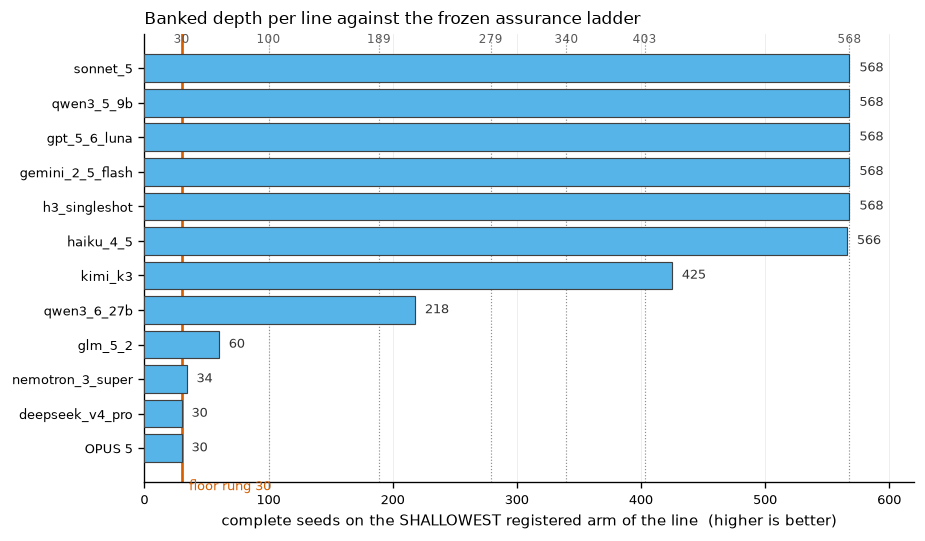

In [5]:
fig, ax = plt.subplots(figsize=(7.6, 4.4))
order = P.sort_values("min arm")
names, banked = list(order["model"]), list(order["min arm"])
bars = ax.barh(names, banked, color=OKABE_ITO["skyblue"], edgecolor="0.25", linewidth=0.7, zorder=3)
for r in LADDER:
    ax.axvline(r, color="0.55", lw=0.7, ls=":", zorder=1)
    ax.text(r, len(names) - 0.35, str(r), ha="center", va="bottom", fontsize=7, color="0.35")
for b, v in zip(bars, banked):
    ax.text(v + 8, b.get_y() + b.get_height() / 2, str(v), va="center", fontsize=7.5, color="0.2")
ax.axvline(FLOOR, color=OKABE_ITO["vermillion"], lw=1.6, zorder=2)
ax.text(FLOOR + 6, -0.9, "floor rung 30", color=OKABE_ITO["vermillion"], fontsize=8, va="top")
ax.set_xlabel("complete seeds on the SHALLOWEST registered arm of the line  (higher is better)")
ax.set_xlim(0, 620)
ax.set_title("Banked depth per line against the frozen assurance ladder", loc="left")
ax.grid(axis="y", visible=False)
savefig(fig, FIGDIR / "F03_campaign_progress.png")
plt.show()

**Figure 3. Banked depth per line against the frozen assurance ladder.** Each bar is the number of
complete seeds held by the *shallowest registered arm* on that line, which is what decides whether
the line has banked a rung. Dotted verticals are the seven registered rungs, the red line the floor.

**What to conclude.** Ten lines have cleared the floor and four sit near the top of the ladder, yet
the study still reports rung zero, because the Opus line reads zero on the two arms that matter.
**The distance between the tallest bar and the reported rung is the price of the minimum rule**, and
it is deliberate: it stops a headline number resting on whichever model happened to get the most
machines.

## 4. The confirmatory result

**This is the only result the study is permitted to report, and it is not in yet.**

The frozen pre-registration scopes the confirmatory look to the Opus arm at the achieved rung. One
model sits in that seat, and the reason is on record: a null measured on a weak model is a
statement about the model rather than about the feedback channel. The leg evidence in Part B
demonstrates that concern rather than merely asserting it.

The cell below fills this section in automatically once the records land.

In [6]:
d_op, s_op = cell("test", "distributional"), cell("test", "scalar")
common_op = d_op.index.intersection(s_op.index)
HAS_OPUS = len(common_op) >= 5

print("=" * 78)
print("CONFIRMATORY ARM: Opus 5   (line 'test' / c1)")
print("=" * 78)
print("  distributional records : %d / %d" % (len(d_op), FLOOR))
print("  scalar records         : %d / %d" % (len(s_op), FLOOR))
print("  paired seeds available : %d" % len(common_op))
print()

if HAS_OPUS:
    out = []
    for metric, label, unit in (("sharpe", "Sharpe", "annualised"),
                                ("oos_cvar_05", "CVaR-5%", "daily return"),
                                ("max_drawdown", "max drawdown", "fraction"),
                                ("sortino", "Sortino", "annualised"),
                                ("turnover_mean", "turnover", "fraction per day")):
        d = paired("test", "distributional", "scalar", metric)
        m, lo, hi = boot_ci(d)
        out.append({"metric": label, "unit": unit, "n": d.size, "diff": m,
                    "lo": lo, "hi": hi, "p": signflip_p(d)})
    display(pd.DataFrame(out))
    print("^ THIS IS THE RESULT. Everything else in this notebook is replication evidence.")
else:
    print("  >>> AWAITING DATA <<<")
    print()
    print("  These two arms run as ONE interleaved array, the H2 pair test, so both share")
    print("  identical seeds. That is what makes the comparison paired. Measured duration for")
    print("  this job shape is 8.4 to 9.2 hours from dispatch.")
    print()
    print("  Re-run with FORCE_RELOAD = True once they land. This panel and every reserved")
    print("  OPUS row in the figures below populate automatically.")

CONFIRMATORY ARM: Opus 5   (line 'test' / c1)
  distributional records : 30 / 30
  scalar records         : 30 / 30
  paired seeds available : 30



,metric,unit,n,diff,lo,hi,p
0,Sharpe,annualised,30,-0.0828,-0.1298,-0.0340,0.0077
1,CVaR-5%,daily return,30,0.0031,0.0025,0.0038,0.0001
2,max drawdown,fraction,30,0.0257,0.0137,0.0388,0.0019
3,Sortino,annualised,30,-0.0927,-0.1406,-0.0430,0.0043
4,turnover,fraction per day,30,0.0287,0.0220,0.0354,0.0001


^ THIS IS THE RESULT. Everything else in this notebook is replication evidence.


**How to read this section once it is populated.** Look at the paired difference and its interval,
not at the p-value. Three readings are possible and they are not the same thing.

- **The interval sits clearly on one side of zero.** The channel changed the outcome, in the
  direction of the sign, on this model, at this rung.
- **The interval straddles zero and is narrow.** Evidence of a bounded effect. This is the
  pre-registered prediction and it is a positive finding, because a tight interval around zero
  rules out effects large enough to matter.
- **The interval straddles zero and is wide.** Inconclusive at this rung, which is not evidence of
  absence. The registered analysis has an explicit branch for this, and at thirty seeds it is the
  likely outcome, because the power calculation puts the seeds needed to declare equivalence at the
  registered margin at roughly one hundred and seventy-three.

**Do not read the point estimate without the interval.** Seed-to-seed noise on this contrast was
measured at 0.369 Sharpe units in the pilot, far larger than any effect anyone expects.

# Part A. What the strategies actually did

Sharpe is one number about a trained allocator. This part reports the rest: the money, the risk,
the shape of the return distribution, and the cost of getting there.

## 5. The full performance panel

**Every arm, every measure that matters, at the common floor.** The table below is the numerical
backbone of everything that follows. Each cell is a mean over seeds 0 to 29.

In [7]:
PANEL_COLS = [
    ("sharpe", "Sharpe"), ("ann_return", "ann.ret"), ("ann_vol", "ann.vol"),
    ("sortino", "Sortino"), ("calmar", "Calmar"), ("max_drawdown", "maxDD"),
    ("oos_cvar_05", "CVaR5%"), ("oos_cvar_01", "CVaR1%"), ("oos_var_05", "VaR5%"),
    ("skew", "skew"), ("kurtosis", "kurt"), ("hit_rate", "hit"),
    ("turnover_mean", "turnover"), ("cost_drag", "costdrag"), ("sharpe_gross", "Sharpe.gr"),
    ("exp_eff_n", "eff.N"), ("exp_hhi", "HHI"), ("total_return", "tot.ret"),
]


def panel(line: str, arms=None) -> pd.DataFrame:
    '''Mean of every performance measure per arm on one line, at the floor seeds.'''
    q = D[(D["line"] == line) & D["floor"]]
    if arms is not None:
        q = q[q["arm"].isin(arms)]
    g = q.groupby("arm").agg(n=("seed", "count"), **{lab: (col, "mean") for col, lab in PANEL_COLS})
    return g.sort_values("Sharpe", ascending=False)


print("=" * 100)
print("A. THE OPUS LINE (the confirmatory model): all arms, seeds 0-%d" % (FLOOR - 1))
print("=" * 100)
display(panel("test"))

A. THE OPUS LINE (the confirmatory model): all arms, seeds 0-29


,n,Sharpe,ann.ret,ann.vol,Sortino,Calmar,maxDD,CVaR5%,CVaR1%,VaR5%,skew,kurt,hit,turnover,costdrag,Sharpe.gr,eff.N,HHI,tot.ret
arm,,,,,,,,,,,,,,,,,,,
baseline_return_minus_turnover,30,1.1609,0.1574,0.1352,1.1677,0.8439,-0.1903,-0.0187,-0.0295,-0.0126,-0.0594,7.3598,0.5396,0.0077,0.0000,1.1751,13.5375,0.0744,1.5511
scalar_cvar5,30,1.1558,0.1580,0.1355,1.1642,0.8700,-0.1851,-0.0187,-0.0291,-0.0127,-0.0248,7.5045,0.5402,0.0214,0.0000,1.1951,11.0932,0.0959,1.5864
placebo,30,1.1454,0.1522,0.1327,1.1485,0.8304,-0.1893,-0.0183,-0.0288,-0.0125,-0.0715,7.2116,0.5405,0.0129,0.0000,1.1700,11.9438,0.0845,1.4762
scalar,30,1.1354,0.1614,0.1414,1.1408,0.8205,-0.2013,-0.0195,-0.0305,-0.0133,-0.0386,7.3743,0.5397,0.0284,0.0000,1.1860,10.8581,0.0942,1.6045
placebo_shuffled,30,1.1047,0.1542,0.1390,1.1129,0.7746,-0.2040,-0.0192,-0.0301,-0.0131,-0.0199,7.3483,0.5370,0.0328,0.0000,1.1640,11.5398,0.0914,1.4927
distributional,30,1.0527,0.1257,0.1187,1.0481,0.7313,-0.1756,-0.0164,-0.0257,-0.0113,-0.1149,6.6880,0.5391,0.0570,0.0001,1.1733,11.4754,0.0898,1.1224
bayes_opt,30,1.0503,0.1248,0.1185,1.0538,0.7484,-0.1725,-0.0163,-0.0250,-0.0114,-0.0758,6.3252,0.5358,0.0333,0.0000,1.1208,10.7987,0.0988,1.1010
random_search,30,0.9203,0.1044,0.1128,0.9278,0.6615,-0.1658,-0.0155,-0.0239,-0.0107,0.0051,6.7826,0.5316,0.0739,0.0001,1.0859,8.3863,0.1255,0.8692
tpe,30,0.8876,0.1181,0.1329,0.8864,0.6048,-0.2089,-0.0184,-0.0286,-0.0128,-0.0763,6.8550,0.5328,0.1228,0.0001,1.1176,9.1245,0.1154,1.0093


In [8]:
print("=" * 100)
print("B. THE TEN REPLICATION MODELS: the five feedback arms, seeds 0-%d" % (FLOOR - 1))
print("=" * 100)
for line in LEG_ORDER:
    print("\n--- %s ---" % pretty(line))
    display(panel(line, LEG_ARMS))

B. THE TEN REPLICATION MODELS: the five feedback arms, seeds 0-29

--- deepseek_v4_pro ---


,n,Sharpe,ann.ret,ann.vol,Sortino,Calmar,maxDD,CVaR5%,CVaR1%,VaR5%,skew,kurt,hit,turnover,costdrag,Sharpe.gr,eff.N,HHI,tot.ret
arm,,,,,,,,,,,,,,,,,,,
scalar,30,1.1781,0.1656,0.1402,1.1867,0.8569,-0.1968,-0.0194,-0.0305,-0.0131,-0.0486,7.3952,0.5396,0.0076,0.0000,1.1917,12.6845,0.0797,1.6667
scalar_cvar5,30,1.1701,0.1638,0.1398,1.1795,0.8334,-0.2003,-0.0194,-0.0304,-0.0131,-0.0395,7.3706,0.5391,0.0141,0.0000,1.1954,13.6542,0.0749,1.6345
distributional,30,1.1627,0.1651,0.1414,1.1695,0.8488,-0.1987,-0.0195,-0.0307,-0.0132,-0.0586,7.2296,0.5397,0.0103,0.0000,1.1812,11.0911,0.0910,1.6715
placebo,30,1.1555,0.1627,0.1406,1.1641,0.8588,-0.1954,-0.0195,-0.0308,-0.0131,-0.0433,7.5220,0.5392,0.0073,0.0000,1.1687,13.5262,0.0745,1.6169
placebo_shuffled,30,1.1181,0.1575,0.1405,1.1229,0.8275,-0.1976,-0.0195,-0.0306,-0.0132,-0.0640,7.3148,0.5387,0.0211,0.0000,1.1556,11.2027,0.0919,1.5341



--- gemini_2_5_flash ---


,n,Sharpe,ann.ret,ann.vol,Sortino,Calmar,maxDD,CVaR5%,CVaR1%,VaR5%,skew,kurt,hit,turnover,costdrag,Sharpe.gr,eff.N,HHI,tot.ret
arm,,,,,,,,,,,,,,,,,,,
scalar_cvar5,30,1.0337,0.1272,0.1224,1.0378,0.7145,-0.1814,-0.0168,-0.0261,-0.0117,-0.0514,6.6337,0.5358,0.0318,0.0000,1.0990,10.2052,0.1035,1.1333
scalar,30,0.7988,0.1224,0.1513,0.8008,0.4927,-0.2549,-0.0212,-0.0331,-0.0144,-0.0505,7.1786,0.5285,0.2161,0.0002,1.1615,9.8382,0.1048,1.0450
placebo,30,0.7960,0.1207,0.1510,0.8088,0.5384,-0.2335,-0.0210,-0.0346,-0.0138,0.1896,10.4609,0.5268,0.1858,0.0002,1.1086,9.5738,0.1137,1.0187
placebo_shuffled,30,0.4949,0.0748,0.1477,0.4959,0.2882,-0.2750,-0.0209,-0.0326,-0.0143,-0.0331,7.2731,0.5183,0.3659,0.0004,1.1218,9.9399,0.1055,0.5442
distributional,30,-0.2162,-0.0424,0.1996,-0.2157,-0.0612,-0.5570,-0.0289,-0.0483,-0.0183,0.4031,14.1860,0.4750,0.8891,0.0009,0.9096,3.5746,0.3786,-0.2782



--- glm_5_2 ---


...

,n,Sharpe,ann.ret,ann.vol,Sortino,Calmar,maxDD,CVaR5%,CVaR1%,VaR5%,skew,kurt,hit,turnover,costdrag,Sharpe.gr,eff.N,HHI,tot.ret
arm,,,,,,,,,,,,,,,,,,,
scalar_cvar5,30,1.2131,0.1617,0.1334,1.2193,0.8206,-0.1984,-0.0188,-0.0298,-0.0122,-0.1026,8.1305,0.5390,0.0364,0.0000,1.2814,29.9768,0.0337,1.5964
placebo,30,1.2087,0.1668,0.1378,1.2158,0.8677,-0.1944,-0.0192,-0.0304,-0.0127,-0.0613,7.7289,0.5407,0.0059,0.0000,1.2194,17.6669,0.0569,1.6832
scalar,30,0.5006,0.0696,0.1386,0.5002,0.2864,-0.2630,-0.0198,-0.0312,-0.0133,-0.0680,7.9760,0.5174,0.3960,0.0004,1.2214,15.3864,0.0684,0.4845
placebo_shuffled,30,0.0579,0.0095,0.1519,0.0590,0.0348,-0.3725,-0.0218,-0.0336,-0.0149,-0.0165,7.1108,0.5041,0.6320,0.0006,1.1120,8.3507,0.1289,0.0049
distributional,30,-0.2582,-0.0421,0.1613,-0.2572,-0.0775,-0.4902,-0.0233,-0.0371,-0.0158,0.1740,9.6297,0.4912,0.8296,0.0008,1.0405,6.1827,0.2087,-0.2746



--- qwen3_6_27b ---


,n,Sharpe,ann.ret,ann.vol,Sortino,Calmar,maxDD,CVaR5%,CVaR1%,VaR5%,skew,kurt,hit,turnover,costdrag,Sharpe.gr,eff.N,HHI,tot.ret
arm,,,,,,,,,,,,,,,,,,,
placebo,30,1.1681,0.1594,0.1361,1.1747,0.8255,-0.1950,-0.0190,-0.0301,-0.0127,-0.0725,7.6655,0.5388,0.0209,0.0000,1.2069,16.8562,0.0596,1.5695
distributional,30,1.1161,0.1580,0.1415,1.1235,0.8130,-0.2018,-0.0196,-0.0311,-0.0132,-0.0648,7.4415,0.5371,0.0328,0.0000,1.1712,12.3949,0.0836,1.5636
scalar_cvar5,30,1.0921,0.1374,0.1247,1.0986,0.7822,-0.1776,-0.0171,-0.0265,-0.0118,-0.0598,6.6357,0.5365,0.0171,0.0000,1.1268,10.8924,0.0942,1.2843
scalar,30,1.0703,0.1562,0.1457,1.0766,0.7467,-0.2152,-0.0202,-0.0316,-0.0137,-0.0287,7.1653,0.5369,0.0494,0.0000,1.1596,9.9859,0.1024,1.5195
placebo_shuffled,30,1.0253,0.1455,0.1415,1.0290,0.7106,-0.2131,-0.0196,-0.0307,-0.0134,-0.0512,7.5469,0.5355,0.1018,0.0001,1.2063,10.9994,0.0934,1.3569



--- sonnet_5 ---


,n,Sharpe,ann.ret,ann.vol,Sortino,Calmar,maxDD,CVaR5%,CVaR1%,VaR5%,skew,kurt,hit,turnover,costdrag,Sharpe.gr,eff.N,HHI,tot.ret
arm,,,,,,,,,,,,,,,,,,,
scalar,30,1.1671,0.1628,0.1389,1.1745,0.8604,-0.1919,-0.0193,-0.0304,-0.0130,-0.0653,7.4391,0.5386,0.0109,0.0000,1.1868,13.0719,0.0778,1.6345
distributional,30,1.0986,0.1530,0.1389,1.1067,0.7639,-0.2036,-0.0193,-0.0300,-0.0131,-0.0512,7.2910,0.5359,0.0475,0.0000,1.1861,11.3188,0.0909,1.4794
placebo,30,1.0981,0.1546,0.1405,1.1058,0.8162,-0.1941,-0.0195,-0.0310,-0.0131,-0.0420,7.6170,0.5369,0.0177,0.0000,1.1299,11.4282,0.0908,1.4988
scalar_cvar5,30,0.9142,0.1019,0.1105,0.9213,0.6442,-0.1613,-0.0151,-0.0232,-0.0105,0.0326,6.6460,0.5322,0.0394,0.0000,1.0051,9.0245,0.1174,0.8471
placebo_shuffled,30,0.3575,0.0527,0.1533,0.3593,0.2648,-0.3324,-0.0220,-0.0345,-0.0148,-0.0229,8.0400,0.5118,0.4501,0.0005,1.0897,11.1751,0.1412,0.4260


**What the panel says before any figure.**

**Most trained allocators are profitable out of sample and broadly similar.** Sharpe clusters
around one, annualised volatility around ten per cent, hit rates a little above one half. That
uniformity is itself a result: a language model given a reward-design task produces working reward
code in almost every configuration on almost every model.

**Kurtosis is high everywhere.** Daily returns are far from normal, which is exactly why the study
measures tails separately rather than trusting Sharpe alone, and why the fed vector is a tail
vector.

**The cost columns deserve attention.** `costdrag` is the daily return lost to transaction costs,
and `Sharpe.gr` is what the strategy would have earned with no costs at all. The gap between
`Sharpe` and `Sharpe.gr` is large on many arms. Section 19 makes that the centre of the mechanism
argument.

## 6. The money: cumulative wealth through the sealed test window

**This is what a pound invested would have done.** The test window runs from 2020 to mid-2026 and
was untouched until final inference, so these are genuine out-of-sample paths.

Each line is the mean across seeds of the cumulative wealth path, which is not the same object as
the path of the mean strategy. It is the honest summary of what the seeds did collectively.

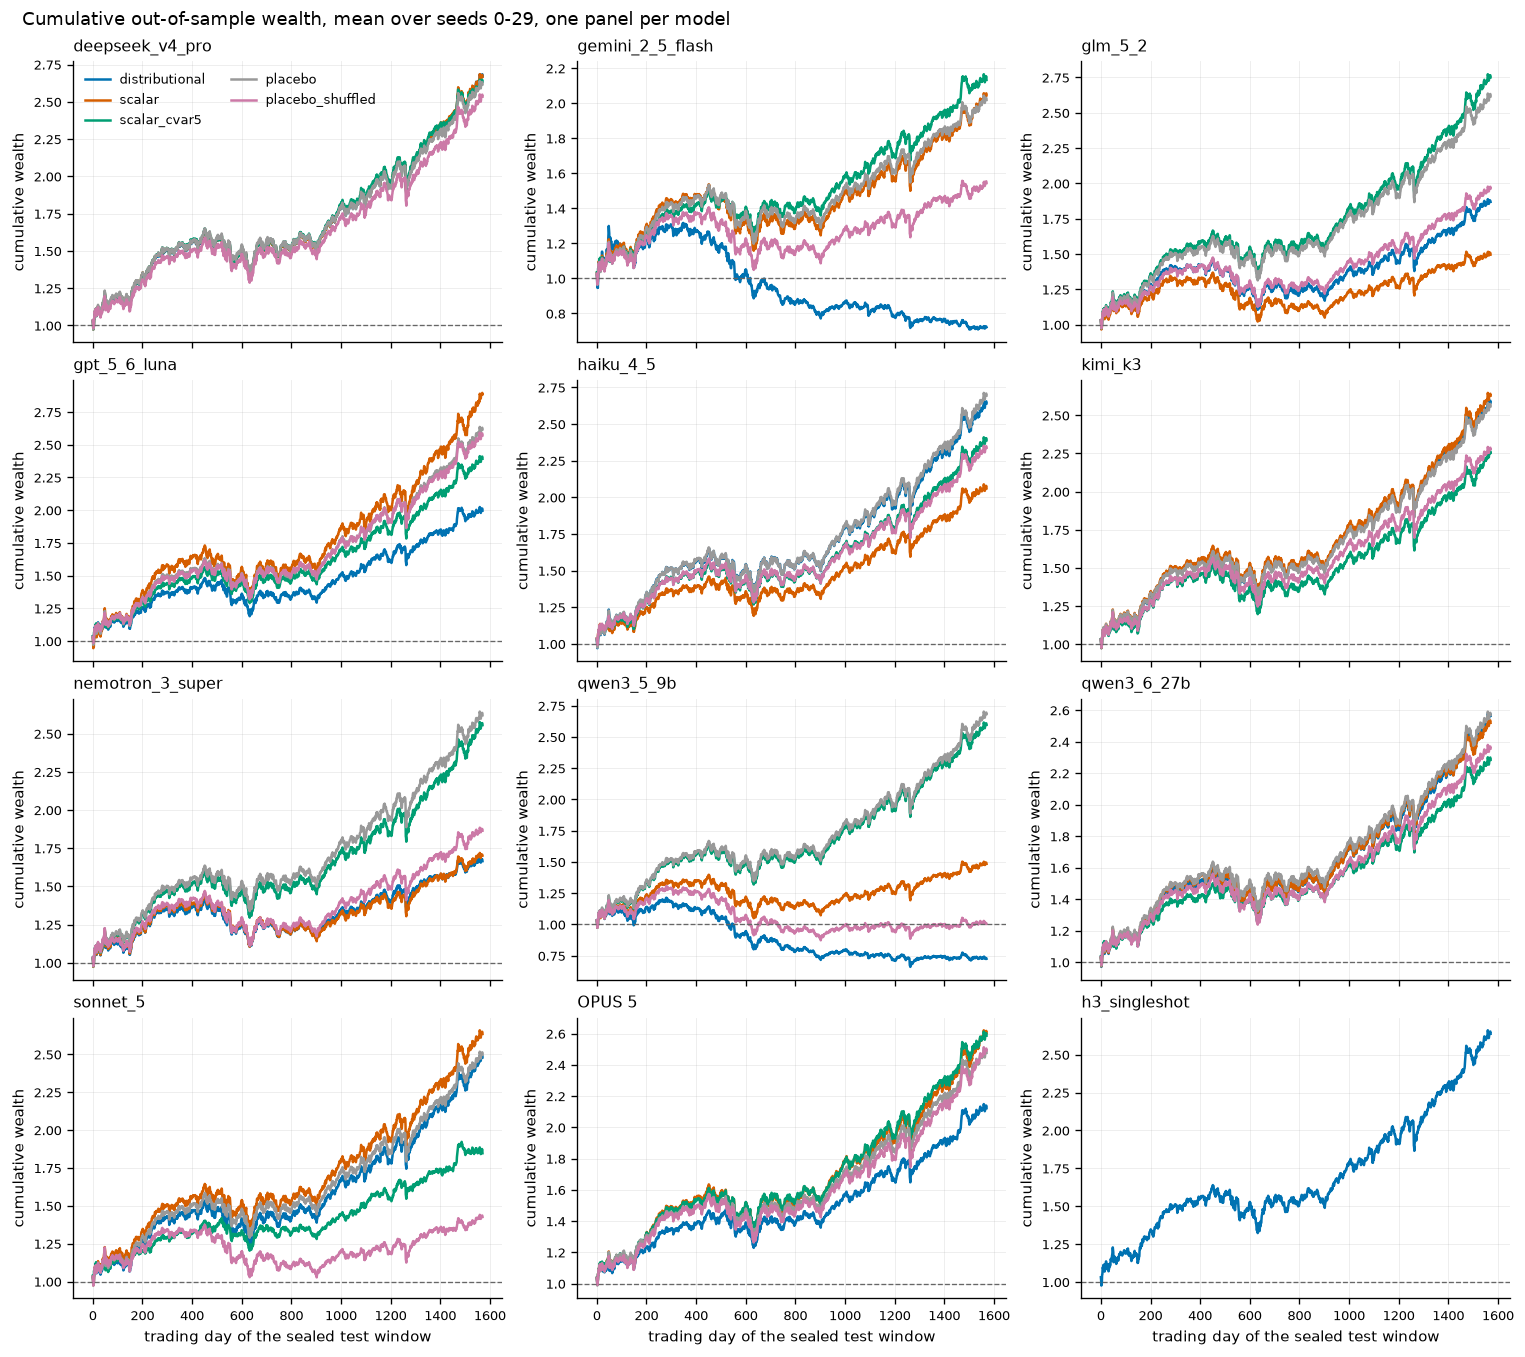

In [9]:
def equity_panel(ax, line, arms, colors=None, title=""):
    for i, arm in enumerate(arms):
        eq = S(line, arm, "equity_mean")
        if eq is None:
            continue
        c = (colors or {}).get(arm) or list(OKABE_ITO.values())[i % 9]
        ax.plot(np.arange(eq.size), eq, lw=1.5, color=c, label=arm)
    ax.axhline(1.0, color="0.4", lw=0.8, ls="--")
    ax.set_title(title, loc="left", fontsize=9.5)
    ax.set_ylabel("cumulative wealth")


ARMC = {"distributional": OKABE_ITO["blue"], "scalar": OKABE_ITO["vermillion"],
        "scalar_cvar5": OKABE_ITO["green"], "placebo": OKABE_ITO["grey"],
        "placebo_shuffled": OKABE_ITO["purple"]}

fig, axes = plt.subplots(4, 3, figsize=(12.6, 11.2), sharex=True)
for ax, line in zip(axes.ravel(), LEG_ORDER + ["test", "test_h3_singleshot"]):
    equity_panel(ax, line, LEG_ARMS, ARMC, pretty(line))
for ax in axes.ravel()[len(LEG_ORDER) + 2:]:
    ax.set_visible(False)
for ax in axes[-1]:
    ax.set_xlabel("trading day of the sealed test window")
axes[0, 0].legend(loc="upper left", fontsize=7.5, ncols=2)
fig.suptitle("Cumulative out-of-sample wealth, mean over seeds 0-29, one panel per model",
             x=0.01, ha="left", fontsize=11)
savefig(fig, FIGDIR / "F06_equity_curves_by_model.png")
plt.show()

**Figure 6. Out-of-sample wealth paths, one panel per model, five feedback arms each.** The dashed
line is the starting capital. A path below it lost money.

**What to conclude.** Most panels show five curves rising together, which is the uniformity the
table already suggested. The exceptions are visible immediately and they are the same two models
that Part B will identify: on `gemini_2_5_flash` and `qwen3_5_9b` the blue `distributional` curve
separates downward from everything else and ends below the starting line.

**This is the exhibit that makes the effect concrete.** A difference of one Sharpe unit is abstract.
A wealth path that ends below where it started is not.

**Read the shapes as well as the ends.** Several curves show a common drawdown early in the window,
which is the 2020 market shock arriving in every arm at once. Arms that differ in their *recovery*
rather than in their exposure to that shock are telling you something about the reward, because
the shock itself was not optional.

## 7. Drawdown: the loss a holder would actually have lived through

**Cumulative wealth hides the worst moment.** Drawdown is the fall from the running peak, and it is
the number a practitioner reacts to, because it is the loss visible while it is happening.

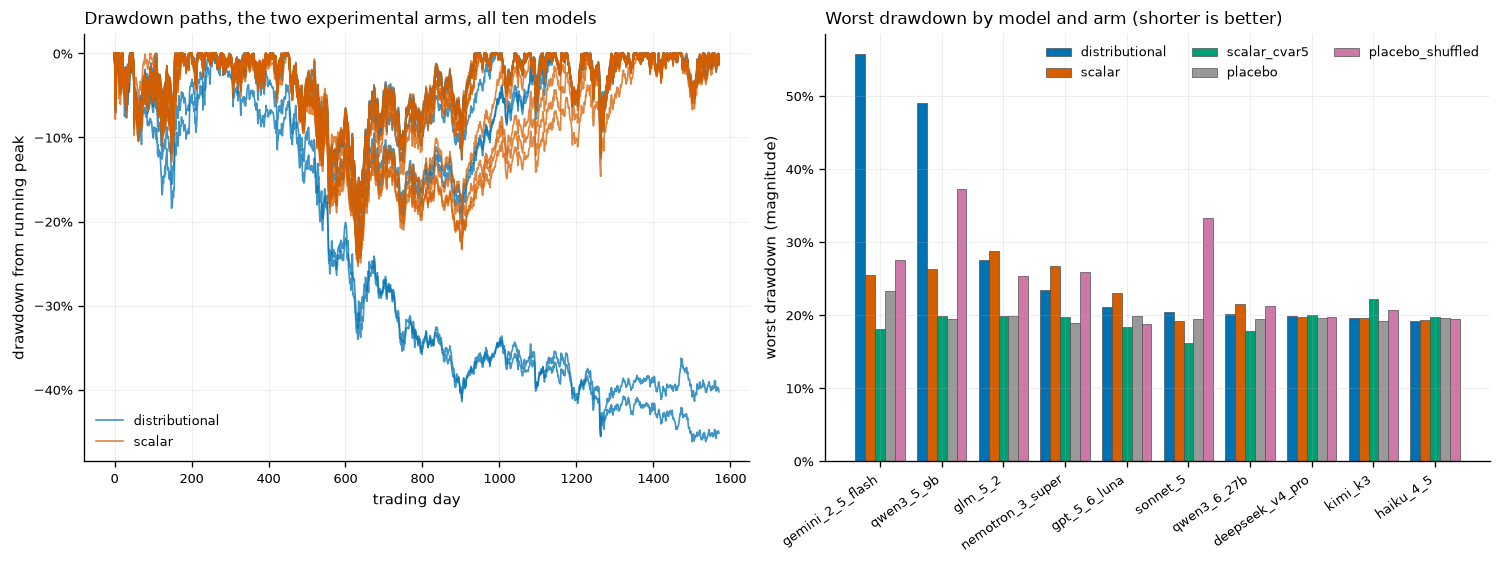

,mean,min,max
arm,,,
distributional,-0.2761,-0.7335,-0.1150
scalar,-0.2296,-0.4128,-0.1148
scalar_cvar5,-0.1918,-0.3359,-0.1035
placebo,-0.1987,-0.3858,-0.1271
placebo_shuffled,-0.2493,-0.5167,-0.1234


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.6))

ax = axes[0]
for arm in H2_ARMS:
    for k, line in enumerate(LEG_ORDER):
        eq = S(line, arm, "equity_mean")
        if eq is None:
            continue
        dd = eq / np.maximum.accumulate(eq) - 1.0
        ax.plot(np.arange(dd.size), dd, lw=1.0, alpha=0.75,
                color=ARMC[arm], label=arm if k == 0 else None)
ax.set_title("Drawdown paths, the two experimental arms, all ten models", loc="left")
ax.set_xlabel("trading day"); ax.set_ylabel("drawdown from running peak")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(loc="lower left")

ax = axes[1]
dd_tbl = (D[D["floor"] & D["arm"].isin(LEG_ARMS) & D["is_leg"]]
          .groupby(["model", "arm"])["max_drawdown"].mean().unstack())
dd_tbl = dd_tbl[list(LEG_ARMS)].sort_values("distributional")
xs = np.arange(len(dd_tbl))
w = 0.16
for i, arm in enumerate(LEG_ARMS):
    ax.bar(xs + (i - 2) * w, -dd_tbl[arm].to_numpy(), width=w, color=ARMC[arm],
           edgecolor="0.3", linewidth=0.4, label=arm)
ax.set_xticks(xs); ax.set_xticklabels(dd_tbl.index, rotation=35, ha="right")
ax.set_ylabel("worst drawdown (magnitude)")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title("Worst drawdown by model and arm (shorter is better)", loc="left")
ax.legend(fontsize=7.5, ncols=3)
savefig(fig, FIGDIR / "F07_drawdown.png")
plt.show()

display(D[D["floor"] & D["arm"].isin(LEG_ARMS) & D["is_leg"]]
        .groupby("arm")["max_drawdown"].agg(["mean", "min", "max"]).loc[list(LEG_ARMS)])

**Figure 7. Left, the drawdown path of each model's two experimental arms. Right, the worst
drawdown reached, by model and arm.**

**What to conclude.** The drawdown paths are dominated by a common event rather than by the reward.
Every arm on every model falls together at the same point in the window, which is the market doing
it rather than the designer. That shared shock is a useful sanity check: it says the arms are
trading the same world.

**The differences appear afterwards.** Where `distributional` ends deeper than `scalar` it is
usually because it failed to recover, not because it was more exposed at the moment of the shock.
That distinction matters for interpretation, because a reward that reduces exposure before a crash
would be a risk-management success, and one that merely fails to recover afterwards is not.

**Note what is not here.** A tail-fed designer might be expected to produce shallower drawdowns
even at the cost of return. On this evidence it does not systematically do so, which is a point
against the simplest reading of how the channel was supposed to work.

## 8. The shape of the returns

**The entire premise of the study is that a single number cannot convey the shape of a
distribution.** This section shows the shapes.

Each histogram pools every daily return across seeds 0 to 29 for that arm, which is roughly forty
seven thousand observations per curve.

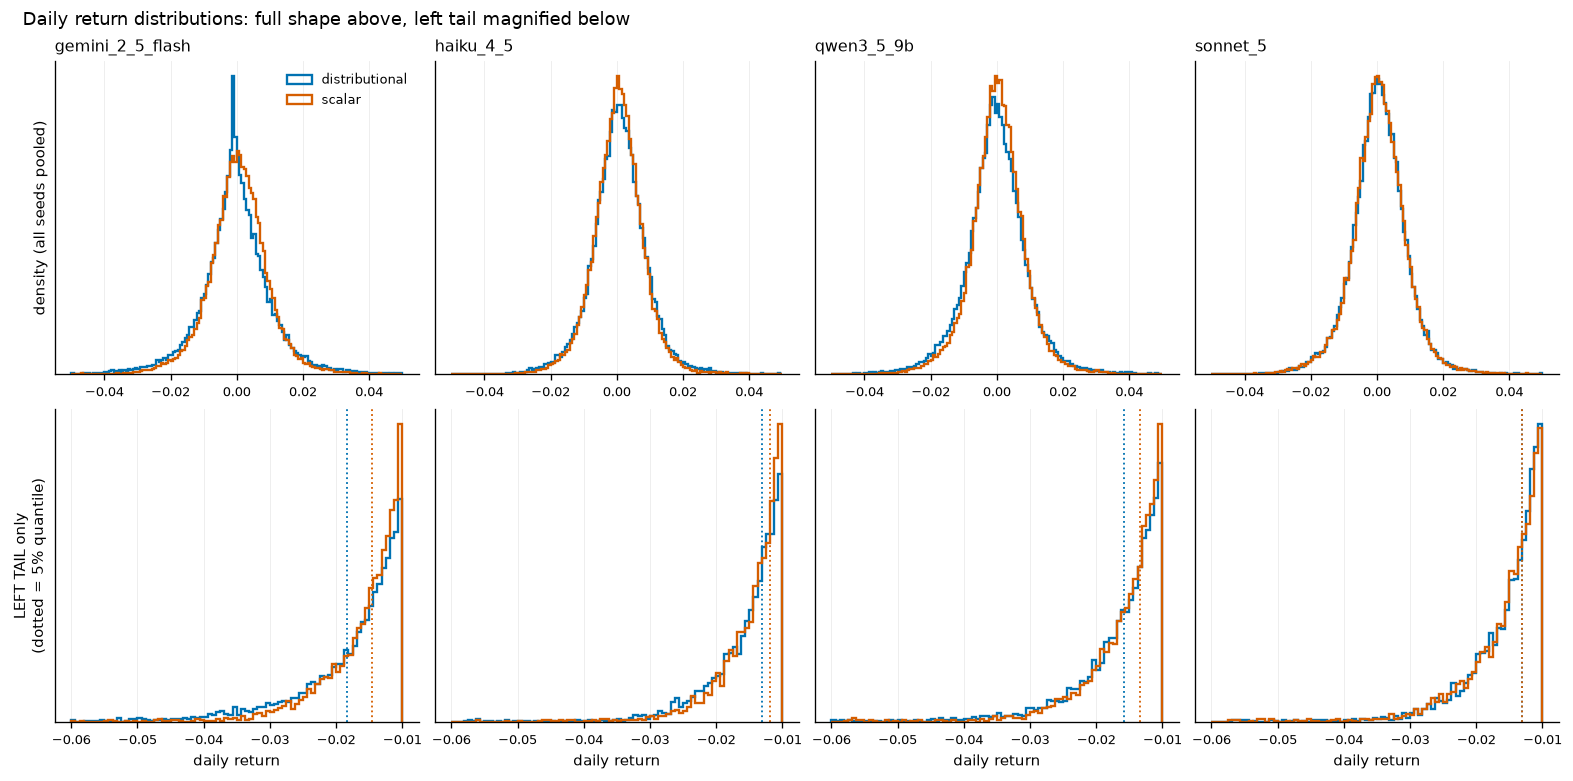

In [11]:
SHOW = ["gemini_2_5_flash", "qwen3_5_9b", "haiku_4_5", "sonnet_5"]
SHOW_LINES = [l for l in LEG_ORDER if pretty(l) in SHOW]

fig, axes = plt.subplots(2, len(SHOW_LINES), figsize=(13.0, 6.4))
for j, line in enumerate(SHOW_LINES):
    ax = axes[0, j]
    for arm in H2_ARMS:
        pool = S(line, arm, "pooled_returns")
        if pool is None:
            continue
        ax.hist(pool, bins=140, range=(-0.05, 0.05), histtype="step", density=True,
                lw=1.4, color=ARMC[arm], label=arm)
    ax.set_title(pretty(line), loc="left", fontsize=9.5)
    ax.set_yticks([])
    if j == 0:
        ax.set_ylabel("density (all seeds pooled)"); ax.legend(fontsize=7.5)

    ax = axes[1, j]
    for arm in H2_ARMS:
        pool = S(line, arm, "pooled_returns")
        if pool is None:
            continue
        ax.hist(pool, bins=80, range=(-0.06, -0.01), histtype="step", density=True,
                lw=1.4, color=ARMC[arm])
        ax.axvline(np.quantile(pool, 0.05), color=ARMC[arm], ls=":", lw=1.1)
    ax.set_xlabel("daily return")
    ax.set_yticks([])
    if j == 0:
        ax.set_ylabel("LEFT TAIL only\n(dotted = 5% quantile)")
fig.suptitle("Daily return distributions: full shape above, left tail magnified below",
             x=0.01, ha="left", fontsize=11)
savefig(fig, FIGDIR / "F08_return_distributions.png")
plt.show()

**Figure 8. Pooled daily return distributions for four models. The top row is the whole
distribution, the bottom row magnifies the left tail below minus one per cent, with the five per
cent quantile marked.**

**What to conclude.** The distributions are sharply peaked with long tails on both sides, which is
what high kurtosis looks like. They are not close to normal, and any reasoning that treats mean and
variance as sufficient is discarding real information. **That is the study's premise, visible
rather than asserted.**

**The bottom row is where the treatment was supposed to act.** The `distributional` arm is the one
shown six tail statistics between attempts, so if the channel worked as intended its left tail
would be visibly thinner than the `scalar` arm's. On `haiku_4_5` there is a modest separation. On
`gemini_2_5_flash` and `qwen3_5_9b` the tail-fed arm is *worse*, which is consistent with the
degradation seen everywhere else for those two models rather than being a separate phenomenon.

**A caution about pooling.** Combining thirty seeds into one histogram mixes within-seed and
between-seed variation. It is the right exhibit for showing shape and the wrong one for inference,
which is why every test in Part B is computed per seed and paired.

## 9. The tail profile, measured on the sealed window

**The six statistics the designer was shown, recomputed on out-of-sample performance.**

⚠ These are the same *formulas* as the fed vector, not the fed vector. The fed vector is measured
in-sample on training returns during the search and routes CVaR-5% through an extreme-value fit.
These are empirical and computed on the sealed test window, so every name carries the `oos_`
prefix. Confusing the two would be a category error.

oos_cvar_01  oos_cvar_05  oos_cvar_10  oos_cvar_25  oos_left_tail_mass  oos_robust_skew
model            arm                                                                                                    
deepseek_v4_pro  distributional      -0.0307      -0.0195      -0.0153      -0.0100              0.0229          -0.0196
                 scalar              -0.0305      -0.0194      -0.0152      -0.0099              0.0230          -0.0214
gemini_2_5_flash distributional      -0.0483      -0.0289      -0.0220      -0.0140              0.0241           0.0053
                 scalar              -0.0331      -0.0212      -0.0167      -0.0110              0.0242          -0.0235
glm_5_2          distributional      -0.0331      -0.0212      -0.0166      -0.0109              0.0244          -0.0198
                 scalar              -0.0335      -0.0213      -0.0167      -0.0110              0.0252          -0.0169
gpt_5_6_luna     distributional      -0.0309      -0.0188      -0.0146      -0.0096              0.0222          -0.0214
                 scalar              -0.0361      -0.0224      -0.0174      -0.0112              0.0227          -0.0260
haiku_4_5        distributional      -0.0308      -0.0195      -0.0152      -0.0099              0.0235          -0.0199
                 scalar              -0.0266      -0.0172      -0.0136      -0.0091              0.0229          -0.0264
kimi_k3          distributional      -0.0301      -0.0190      -0.0149      -0.0097              0.0229          -0.0198
                 scalar              -0.0308      -0.0195      -0.0152      -0.0099              0.0227          -0.0225
nemotron_3_super distributional      -0.0301      -0.0191      -0.0150      -0.0099              0.0245          -0.0245
                 scalar              -0.0337      -0.0215      -0.0169      -0.0111              0.0245          -0.0176
qwen3_5_9b       distributional      -0.0371      -0.0233      -0.0183      -0.0120              0.0252          -0.0159
                 scalar              -0.0312      -0.0198      -0.0154      -0.0101              0.0251          -0.0221
qwen3_6_27b      distributional      -0.0311      -0.0196      -0.0153      -0.0100              0.0227          -0.0219
                 scalar              -0.0316      -0.0202      -0.0159      -0.0104              0.0244          -0.0215
sonnet_5         distributional      -0.0300      -0.0193      -0.0151      -0.0099              0.0234          -0.0205
                 scalar              -0.0304      -0.0193      -0.0151      -0.0098              0.0235          -0.0215

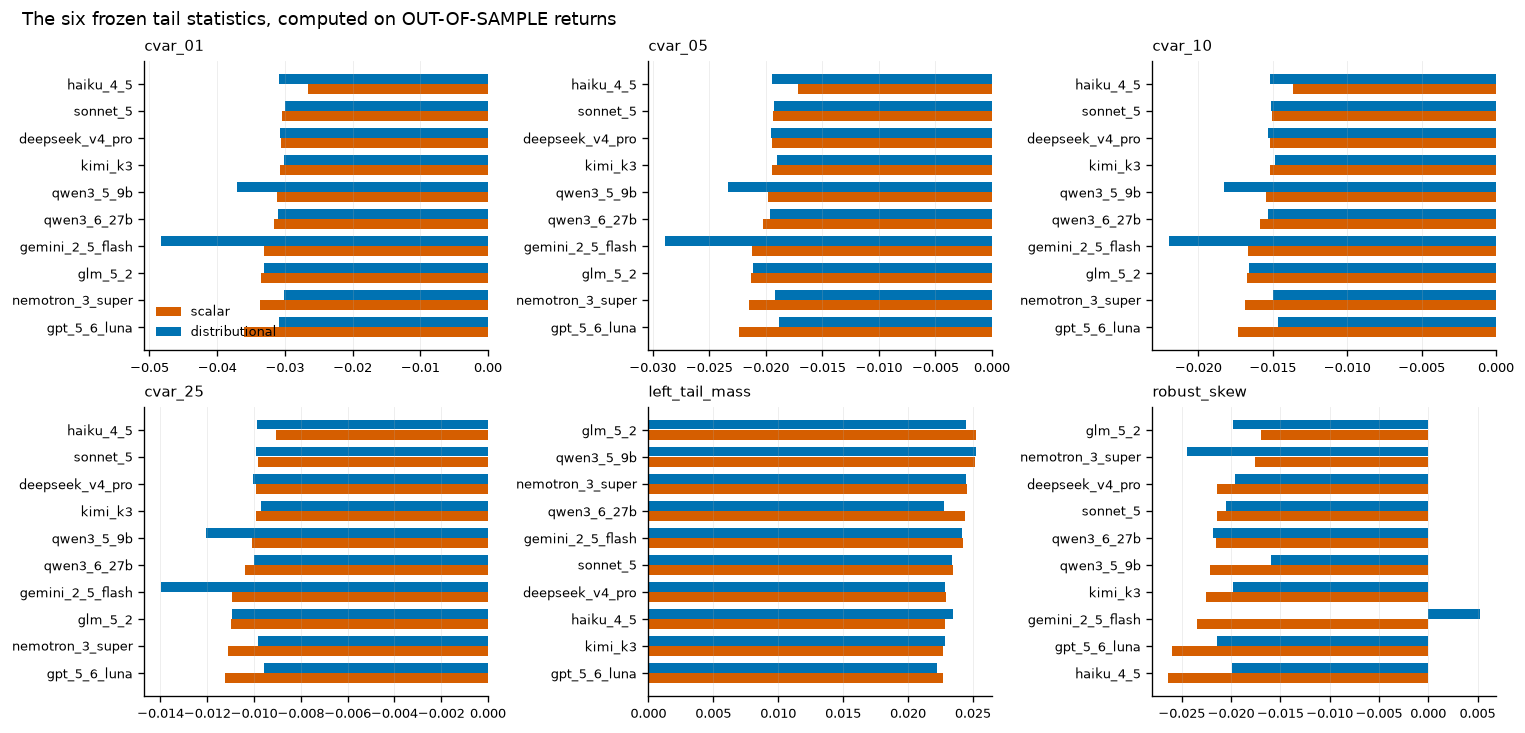

In [12]:
TAILC = ["oos_cvar_01", "oos_cvar_05", "oos_cvar_10", "oos_cvar_25",
         "oos_left_tail_mass", "oos_robust_skew"]

T = (D[D["floor"] & D["is_leg"] & D["arm"].isin(H2_ARMS)]
     .groupby(["model", "arm"])[TAILC].mean())
display(T)

fig, axes = plt.subplots(2, 3, figsize=(12.6, 6.0))
for ax, col in zip(axes.ravel(), TAILC):
    piv = T[col].unstack()[list(H2_ARMS)].sort_values("scalar")
    y = np.arange(len(piv))
    ax.barh(y - 0.19, piv["scalar"], height=0.36, color=ARMC["scalar"], label="scalar")
    ax.barh(y + 0.19, piv["distributional"], height=0.36, color=ARMC["distributional"],
            label="distributional")
    ax.set_yticks(y); ax.set_yticklabels(piv.index, fontsize=7.5)
    ax.set_title(col.replace("oos_", ""), loc="left", fontsize=9)
    ax.grid(axis="y", visible=False)
axes[0, 0].legend(fontsize=7.5, loc="lower left")
fig.suptitle("The six frozen tail statistics, computed on OUT-OF-SAMPLE returns",
             x=0.01, ha="left", fontsize=11)
savefig(fig, FIGDIR / "F09_tail_profile.png")
plt.show()

**Figure 9. The six tail statistics by model and experimental arm.** The four CVaR levels are in
daily return units and closer to zero is better. `left_tail_mass` is the share of days beyond two
standard deviations to the downside. `robust_skew` is negative when the left tail is longer.

**What to conclude.** The four CVaR levels move together, which is expected because they are nested
tail averages of one distribution. That is a coherence check on the measurement rather than four
independent findings, and reporting them as four separate results would overstate the evidence.

**`left_tail_mass` is the most interesting of the six.** It is a *count* rather than a magnitude, so
it separates a distribution with a few catastrophic days from one with many mildly bad days. Two
arms can share a CVaR and differ here.

**The honest summary is that the tail-fed arm does not systematically produce a thinner tail.** If
the channel worked in the direct way the design imagined, `distributional` would sit closer to zero
on the CVaR panels across the board. It does not.

## 10. Risk against return

**Where every arm sits in the plane a practitioner actually looks at.**

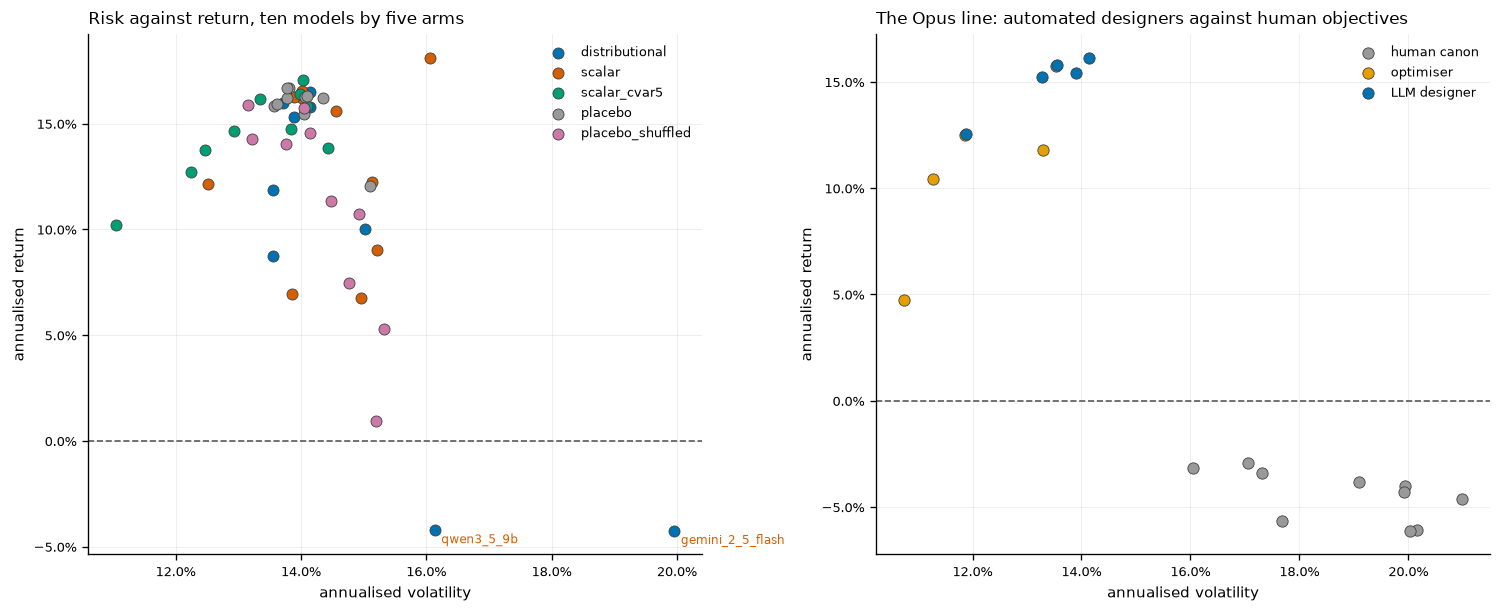

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 5.0))

ax = axes[0]
q = D[D["floor"] & D["is_leg"] & D["arm"].isin(LEG_ARMS)].groupby(["model", "arm"])[
    ["ann_vol", "ann_return", "sharpe"]].mean().reset_index()
for arm in LEG_ARMS:
    s = q[q["arm"] == arm]
    ax.scatter(s["ann_vol"], s["ann_return"], s=44, color=ARMC[arm], label=arm,
               edgecolor="0.25", linewidth=0.5, zorder=3)
ax.axhline(0.0, color="0.35", lw=1.0, ls="--")
for _, r in q[q["ann_return"] < 0].iterrows():
    ax.annotate(r["model"], (r["ann_vol"], r["ann_return"]), fontsize=7,
                xytext=(4, -8), textcoords="offset points", color=OKABE_ITO["vermillion"])
ax.set_xlabel("annualised volatility"); ax.set_ylabel("annualised return")
ax.xaxis.set_major_formatter(PercentFormatter(1.0)); ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title("Risk against return, ten models by five arms", loc="left")
ax.legend(fontsize=7.5)

ax = axes[1]
qo = D[(D["line"] == "test") & D["floor"]].groupby("arm")[["ann_vol", "ann_return"]].mean()
kind = {a: ("human canon" if a.startswith("baseline_") else
            "optimiser" if a in DFO_ARMS else "LLM designer") for a in qo.index}
KC = {"human canon": OKABE_ITO["grey"], "optimiser": OKABE_ITO["orange"],
      "LLM designer": OKABE_ITO["blue"]}
for k, c in KC.items():
    s = qo[[kind[a] == k for a in qo.index]]
    ax.scatter(s["ann_vol"], s["ann_return"], s=46, color=c, label=k,
               edgecolor="0.25", linewidth=0.5, zorder=3)
ax.axhline(0.0, color="0.35", lw=1.0, ls="--")
ax.set_xlabel("annualised volatility"); ax.set_ylabel("annualised return")
ax.xaxis.set_major_formatter(PercentFormatter(1.0)); ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title("The Opus line: automated designers against human objectives", loc="left")
ax.legend(fontsize=7.5)
savefig(fig, FIGDIR / "F10_risk_return.png")
plt.show()

**Figure 10. Left, every model and feedback arm in volatility-return space. Right, the Opus line
with arms grouped by what produced them.**

**What to conclude from the left panel.** Almost every point sits in a tight cluster at roughly ten
per cent volatility and a positive return. The outliers are labelled, and they are negative-return
points rather than high-risk points. **The failures here are failures of return, not of risk
control**, which is worth stating precisely because a tail-feedback study invites the assumption
that anything going wrong went wrong through risk.

**The right panel is the H1 and H4 picture in one frame.** The human objectives sit at similar
volatility to the automated arms and deliver negative return. They are not taking less risk for
less reward. They are taking comparable risk for a worse outcome, which is the honest form of the
claim and a stronger one than a Sharpe ranking alone.

# Part B. The experiment

Everything so far described what the strategies did. This part answers the question the study was
built to ask: **does what the designer is shown change what it writes, and does that change the
outcome?**

Every contrast is **paired on seeds** and truncated to the common floor.

## 11. The headline contrast, across ten models

**There is no single effect of tail feedback. The direction depends on the model.**

In [14]:
H2 = []
for line in LEGS:
    d_sh = paired(line, "distributional", "scalar", "sharpe")
    if d_sh.size < 5:
        continue
    row = {"model": pretty(line), "n": int(d_sh.size), "d_sharpe": d_sh}
    for metric, key in (("sharpe", "sh"), ("oos_cvar_05", "cv")):
        d = paired(line, "distributional", "scalar", metric)
        m, lo, hi = boot_ci(d)
        row[key] = m; row[key + "_lo"] = lo; row[key + "_hi"] = hi
        row[key + "_p"] = signflip_p(d)
        row[key + "_dz"] = float(d.mean() / d.std(ddof=1)) if d.std(ddof=1) > 0 else np.nan
    H2.append(row)
H2.sort(key=lambda r: r["sh"])
for key in ("sh", "cv"):
    for r, a in zip(H2, benjamini_hochberg(np.array([x[key + "_p"] for x in H2]))):
        r[key + "_q"] = float(a)

tbl = pd.DataFrame([{k: v for k, v in r.items() if k != "d_sharpe"} for r in H2])
display(tbl[["model", "n", "sh", "sh_lo", "sh_hi", "sh_p", "sh_q", "sh_dz",
             "cv", "cv_lo", "cv_hi", "cv_q"]])

clash = [r for r in H2 if (r["sh_lo"] * r["sh_hi"] > 0) != (r["sh_q"] < 0.05)]
if clash:
    print("!! interval and corrected permutation test DISAGREE on:",
          ", ".join("%s (q=%.3f)" % (r["model"], r["sh_q"]) for r in clash))
    print("   at n=30 this is expected. The stricter of the two governs.")
else:
    print("the interval and the corrected permutation test agree on every row.")

,model,n,sh,sh_lo,sh_hi,sh_p,sh_q,sh_dz,cv,cv_lo,cv_hi,cv_q
0,gemini_2_5_flash,30,-1.0150,-1.1125,-0.9141,0.0001,0.0002,-2.9822,-0.0077,-0.0086,-0.0067,0.0002
1,qwen3_5_9b,30,-0.7587,-0.8462,-0.6767,0.0001,0.0002,-2.6095,-0.0035,-0.0040,-0.0031,0.0002
2,gpt_5_6_luna,30,-0.2467,-0.3081,-0.1864,0.0001,0.0002,-1.1871,0.0036,0.0026,0.0045,0.0002
3,sonnet_5,30,-0.0685,-0.1097,-0.0298,0.0106,0.0212,-0.5009,0.0001,-0.0004,0.0006,0.8476
4,deepseek_v4_pro,30,-0.0154,-0.0413,0.0112,0.3548,0.4146,-0.1711,-0.0001,-0.0006,0.0004,0.8476
5,kimi_k3,30,0.0028,-0.0387,0.0488,0.9229,0.9229,0.0187,0.0004,-0.0001,0.0009,0.2887
6,qwen3_6_27b,30,0.0458,-0.0186,0.1082,0.2602,0.3717,0.2117,0.0006,-0.0000,0.0012,0.2141
7,nemotron_3_super,30,0.0601,-0.0516,0.1694,0.3732,0.4146,0.1624,0.0023,0.0011,0.0035,0.0156
8,glm_5_2,30,0.2074,0.0327,0.3798,0.0626,0.1043,0.3563,0.0001,-0.0005,0.0008,0.8476
9,haiku_4_5,30,0.2088,0.1715,0.2448,0.0001,0.0002,1.6856,-0.0023,-0.0028,-0.0018,0.0002


!! interval and corrected permutation test DISAGREE on: glm_5_2 (q=0.104)
   at n=30 this is expected. The stricter of the two governs.


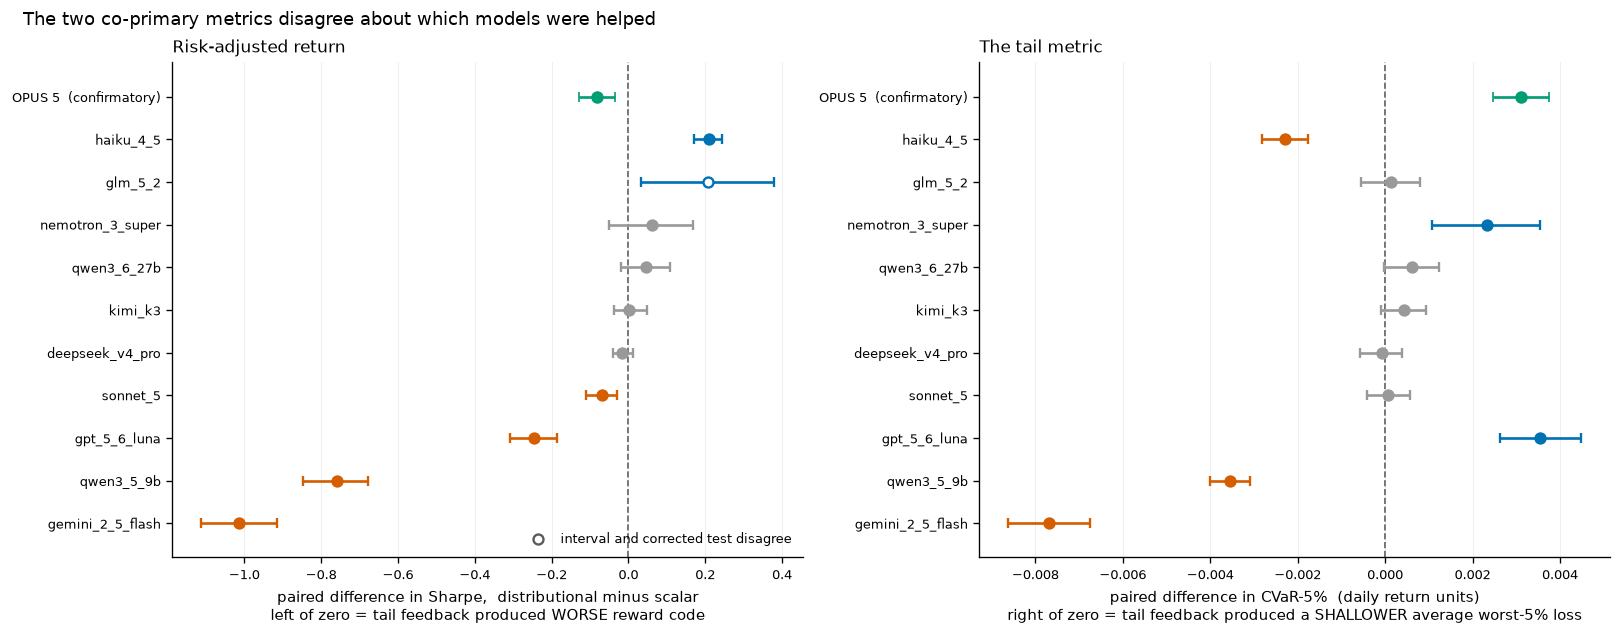

In [15]:
def forest(ax, recs, key, xlabel, title, has_opus, opus_metric):
    labels = [r["model"] for r in recs]
    for i, r in enumerate(recs):
        sig = r[key + "_lo"] * r[key + "_hi"] > 0
        c = OKABE_ITO["vermillion"] if (sig and r[key] < 0) else OKABE_ITO["blue"] if sig else OKABE_ITO["grey"]
        agree = sig == (r[key + "_q"] < 0.05)          # hollow marks DISAGREEMENT only
        ax.errorbar(r[key], i, xerr=[[r[key] - r[key + "_lo"]], [r[key + "_hi"] - r[key]]],
                    fmt="o", color=c, ecolor=c, markerfacecolor=(c if agree else "white"),
                    markeredgewidth=1.4, elinewidth=1.6, capsize=3, markersize=6, zorder=3)
    labels.append("OPUS 5  (confirmatory)")
    i = len(labels) - 1
    if has_opus:
        m, lo, hi = boot_ci(paired("test", "distributional", "scalar", opus_metric))
        ax.errorbar(m, i, xerr=[[m - lo], [hi - m]], fmt="o", color=OKABE_ITO["green"],
                    ecolor=OKABE_ITO["green"], elinewidth=1.6, capsize=3, markersize=6.5, zorder=4)
    else:
        ax.axhspan(i - 0.45, i + 0.45, color=OKABE_ITO["green"], alpha=0.10, zorder=0)
        ax.text(0.0, i, "  AWAITING  (jobs running)", color=OKABE_ITO["green"], fontsize=8.5,
                va="center", ha="left", style="italic")
    ax.axvline(0.0, color="0.35", lw=1.0, ls="--", zorder=1)
    ax.set_yticks(np.arange(len(labels))); ax.set_yticklabels(labels)
    ax.set_ylim(-0.8, len(labels) - 0.2)
    ax.set_xlabel(xlabel); ax.set_title(title, loc="left")
    ax.grid(axis="y", visible=False)


fig, axes = plt.subplots(1, 2, figsize=(13.4, 5.2))
forest(axes[0], H2, "sh",
       "paired difference in Sharpe,  distributional minus scalar\nleft of zero = tail feedback produced WORSE reward code",
       "Risk-adjusted return", HAS_OPUS, "sharpe")
forest(axes[1], H2, "cv",
       "paired difference in CVaR-5%  (daily return units)\nright of zero = tail feedback produced a SHALLOWER average worst-5% loss",
       "The tail metric", HAS_OPUS, "oos_cvar_05")
axes[0].plot([], [], "o", color="0.35", markerfacecolor="white", markeredgewidth=1.4,
             label="interval and corrected test disagree")
axes[0].legend(loc="lower right", fontsize=7.5)
fig.suptitle("The two co-primary metrics disagree about which models were helped",
             x=0.01, ha="left", fontsize=11)
savefig(fig, FIGDIR / "F11_h2_forest_both.png")
plt.show()

**Figure 11. The paired effect of tail feedback on both co-primary metrics, one row per model.**
Points are mean paired differences with ninety per cent bootstrap intervals over seeds. Red is a
detected loss, blue a detected gain, grey an interval covering zero. A hollow marker means the
interval and the multiplicity-corrected permutation test disagree, so that row is suggestive rather
than established. The bottom row is reserved for the confirmatory arm.

**What to conclude.** The rows do not share a sign. Several models are made worse by tail feedback,
a couple are made better, and the rest show no detectable difference. **Averaging these into one
number would destroy the finding rather than summarise it**, and reporting only the average would
be the single most misleading thing this notebook could do.

**The two panels are not the same ordering, and that is why the design registers two co-primary
tests.** A model can be pushed toward worse risk-adjusted return while its tail improves, or the
reverse. Declaring the study on Sharpe alone would have smuggled in an assumption about which
direction the channel was supposed to move.

### The mechanism this points at

**Look at the two Qwen rows.** They are the same family from the same provider at the same
quantisation, differing only in size, and they sit in the design specifically as a controlled
capability contrast. The nine-billion model is near the bottom. The twenty-seven billion model is
in the indistinguishable middle.

That is the numeracy-bottleneck hypothesis appearing exactly where the design predicted. The claim
is not that tail feedback is harmful. It is that **a designer that cannot reliably read six small
floating-point numbers does worse when handed six of them than when handed one**, because the extra
numbers are noise to it rather than signal. Independent evidence supports the premise: measured
authoring reliability is around seventeen per cent for the small model against eighty-three per
cent for its larger sibling.

**The counter-explanation this figure cannot rule out.** The contrast is between two authoring
loops, not two otherwise-identical prompts. A model that writes worse code under tail feedback may
be failing at reading, at using, or at expressing what it read. Separating those is what the
responsiveness and mediation instruments are for, and they are not in this notebook.

## 12. The same contrast, across every measure

**One metric can mislead. Here is the effect on all of them at once.**

Cells are standardised paired effect sizes: the mean paired difference divided by its
standard deviation across seeds. That makes measures on different units comparable, and a value
near zero means the arms are indistinguishable on that measure regardless of its scale.

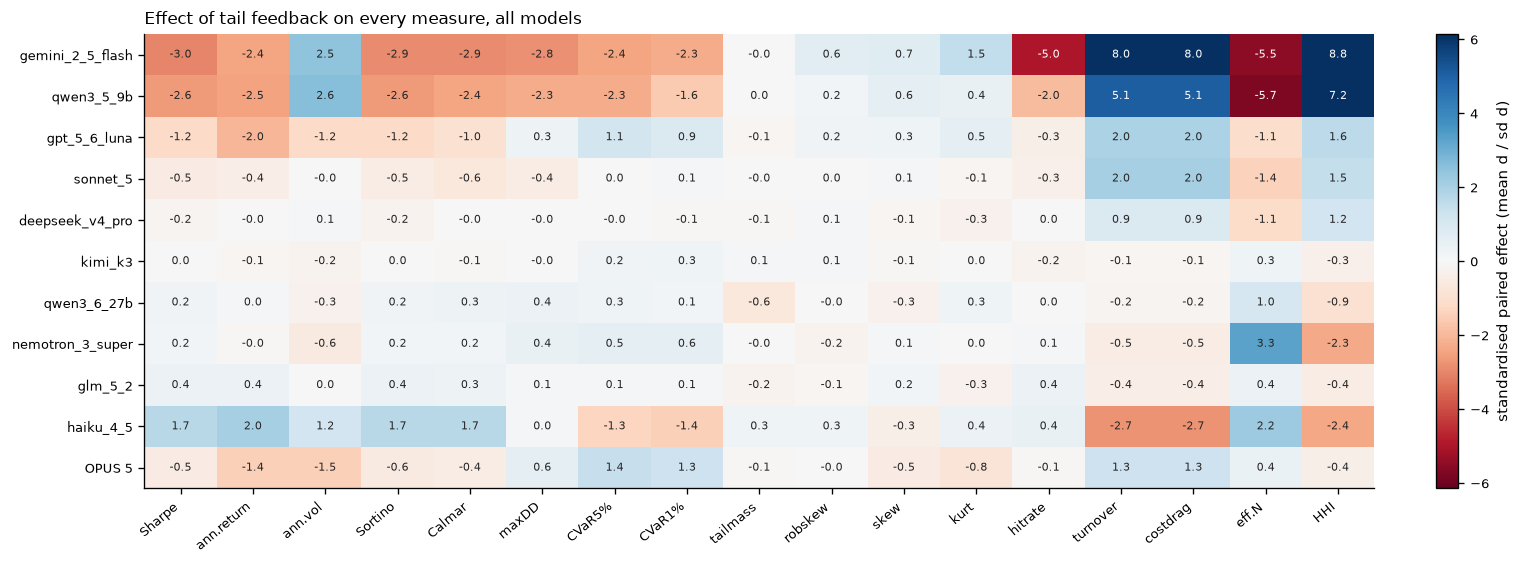

|effect| > 0.5 counts, by measure (out of 11 models):
   Sharpe        strong on 6 model(s),  mean effect -0.50
   ann.return    strong on 5 model(s),  mean effect -0.59
   ann.vol       strong on 6 model(s),  mean effect +0.25
   Sortino       strong on 5 model(s),  mean effect -0.49
   Calmar        strong on 5 model(s),  mean effect -0.45
   maxDD         strong on 3 model(s),  mean effect -0.33
   CVaR5%        strong on 6 model(s),  mean effect -0.22
   CVaR1%        strong on 6 model(s),  mean effect -0.19
   tailmass      strong on 1 model(s),  mean effect -0.07
   robskew       strong on 1 model(s),  mean effect +0.10
   skew          strong on 2 model(s),  mean effect +0.05
   kurt          strong on 3 model(s),  mean effect +0.16
   hitrate       strong on 2 model(s),  mean effect -0.63
   turnover      strong on 7 model(s),  mean effect +1.40
   costdrag      strong on 7 model(s),  mean effect +1.40
   eff.N         strong on 8 model(s),  mean effect -0.66
   HHI           s

In [16]:
EFFECT_METRICS = [
    ("sharpe", "Sharpe"), ("ann_return", "ann.return"), ("ann_vol", "ann.vol"),
    ("sortino", "Sortino"), ("calmar", "Calmar"), ("max_drawdown", "maxDD"),
    ("oos_cvar_05", "CVaR5%"), ("oos_cvar_01", "CVaR1%"),
    ("oos_left_tail_mass", "tailmass"), ("oos_robust_skew", "robskew"),
    ("skew", "skew"), ("kurtosis", "kurt"), ("hit_rate", "hitrate"),
    ("turnover_mean", "turnover"), ("cost_drag", "costdrag"),
    ("exp_eff_n", "eff.N"), ("exp_hhi", "HHI"),
]

M, labels = [], []
for line in [r["model"] for r in H2]:
    src = next(l for l in LEGS if pretty(l) == line)
    row = []
    for col, _ in EFFECT_METRICS:
        d = paired(src, "distributional", "scalar", col)
        s = d.std(ddof=1) if d.size > 1 else 0.0
        row.append(float(d.mean() / s) if s > 0 else np.nan)
    M.append(row); labels.append(line)
if HAS_OPUS:
    row = []
    for col, _ in EFFECT_METRICS:
        d = paired("test", "distributional", "scalar", col)
        s = d.std(ddof=1) if d.size > 1 else 0.0
        row.append(float(d.mean() / s) if s > 0 else np.nan)
    M.append(row); labels.append("OPUS 5")
E = np.array(M, dtype=float)

fig, ax = plt.subplots(figsize=(12.6, 4.6))
v = np.nanpercentile(np.abs(E), 98)
im = ax.imshow(E, cmap="RdBu", vmin=-v, vmax=v, aspect="auto")
ax.set_xticks(range(len(EFFECT_METRICS)))
ax.set_xticklabels([lab for _, lab in EFFECT_METRICS], rotation=40, ha="right")
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
for i in range(E.shape[0]):
    for j in range(E.shape[1]):
        val = E[i, j]
        if np.isfinite(val):
            ax.text(j, i, "%.1f" % val, ha="center", va="center", fontsize=6.8,
                    color="0.15" if abs(val) < v * 0.6 else "white")
fig.colorbar(im, ax=ax, label="standardised paired effect (mean d / sd d)")
ax.set_title("Effect of tail feedback on every measure, all models", loc="left")
ax.grid(False)
savefig(fig, FIGDIR / "F12_effect_all_metrics.png")
plt.show()

print("|effect| > 0.5 counts, by measure (out of %d models):" % E.shape[0])
for j, (_, lab) in enumerate(EFFECT_METRICS):
    col = E[:, j]
    print("   %-12s  strong on %d model(s),  mean effect %+0.2f" %
          (lab, int(np.nansum(np.abs(col) > 0.5)), np.nanmean(col)))

**Figure 12. Standardised paired effect of tail feedback on seventeen measures.** Blue means the
tail-fed arm scored higher on that measure, red lower, and the sign should be read with the
measure's own direction in mind. `maxDD` and the CVaR columns are negative-is-worse quantities, so
blue there means a shallower loss.

**What to conclude.** The effect is not confined to Sharpe. On the models where the channel bites,
it moves return, drawdown, tail and turnover together, which is the signature of **a different
strategy being learned** rather than the same strategy scoring differently. A change confined to
one measure would have suggested a measurement artefact. This does not look like one.

**The rows are far more variable than the columns.** Which model was used matters much more than
which measure is examined, and that is the central preliminary finding of this notebook.

**The turnover column is the one to carry into Part C.** Where it moves, the cost column moves with
it, and Section 19 shows that trading costs are large enough for that to be the mechanism rather
than a side effect.

## 13. Differences hide the thing that matters most

**Two models do not merely do worse under tail feedback. They produce reward code that loses
money.** A difference of minus one Sharpe unit reads differently once you see it runs from a
healthy positive level to a negative one.

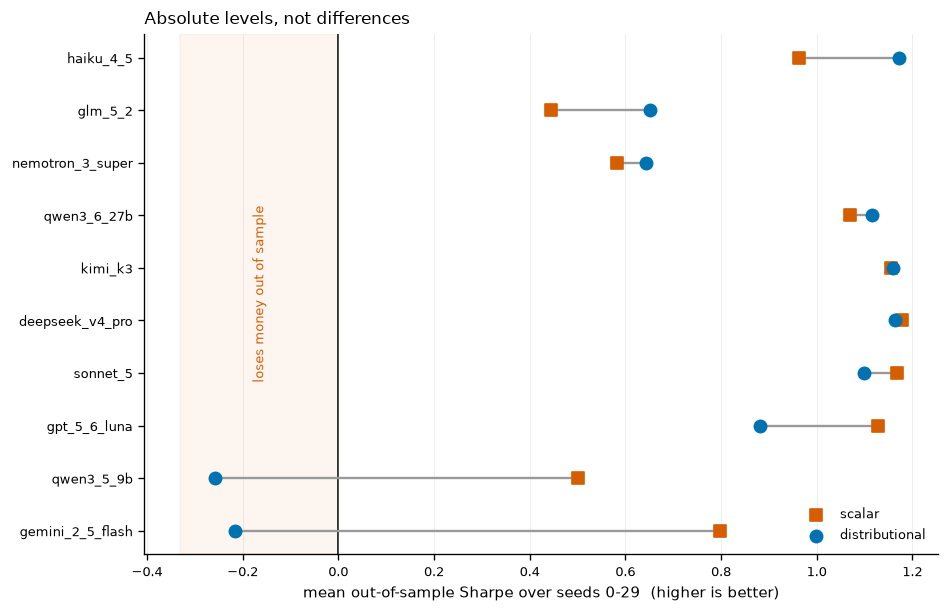

  gemini_2_5_flash     scalar +0.799  ->  distributional -0.216   CROSSES ZERO
  qwen3_5_9b           scalar +0.501  ->  distributional -0.258   CROSSES ZERO


In [17]:
fig, ax = plt.subplots(figsize=(7.8, 5.0))
lv = []
for line in LEGS:
    dd, ds = cell(line, "distributional"), cell(line, "scalar")
    common = dd.index.intersection(ds.index)
    if len(common) < 5:
        continue
    lv.append((pretty(line), float(ds.loc[common].mean()), float(dd.loc[common].mean())))
lv.sort(key=lambda t: t[2] - t[1])

for i, (name, s_lvl, d_lvl) in enumerate(lv):
    ax.plot([s_lvl, d_lvl], [i, i], color="0.6", lw=1.4, zorder=2)
    ax.scatter(s_lvl, i, s=48, color=ARMC["scalar"], marker="s", zorder=3,
               label="scalar" if i == 0 else None)
    ax.scatter(d_lvl, i, s=54, color=ARMC["distributional"], marker="o", zorder=4,
               label="distributional" if i == 0 else None)
ax.axvline(0.0, color="0.2", lw=1.2, zorder=1)
xlo = ax.get_xlim()[0]
ax.axvspan(xlo, 0.0, color=OKABE_ITO["vermillion"], alpha=0.06, zorder=0)
ax.text(xlo / 2, (len(lv) - 1) / 2, "loses money out of sample", rotation=90,
        ha="center", va="center", fontsize=8, color=OKABE_ITO["vermillion"])
ax.set_yticks(np.arange(len(lv))); ax.set_yticklabels([t[0] for t in lv])
ax.set_xlabel("mean out-of-sample Sharpe over seeds 0-%d  (higher is better)" % (FLOOR - 1))
ax.set_title("Absolute levels, not differences", loc="left")
ax.legend(loc="lower right"); ax.grid(axis="y", visible=False)
savefig(fig, FIGDIR / "F13_levels_dumbbell.png")
plt.show()

for name, s_lvl, d_lvl in lv:
    if d_lvl < 0 <= s_lvl:
        print("  %-20s scalar %+0.3f  ->  distributional %+0.3f   CROSSES ZERO" % (name, s_lvl, d_lvl))

**Figure 13. Where each model's two arms sit, rather than how far apart they are.** Squares are the
scalar-fed arm, circles the tail-fed arm, and the connecting line is the effect from Figure 11.

**What to conclude.** For most models both arms sit in a tight band a little above one, which is
what a designer that has found a competent reward looks like whatever it was shown. Two models
break the pattern, both in the same direction and the same way: the scalar arm is fine and the
tail-fed arm is not.

**This is the strongest single piece of mechanism evidence available so far.** The failure is not a
small degradation spread evenly. It is concentrated, large, and lands on exactly the models the
capability argument predicts. A story in which tail feedback is mildly unhelpful cannot produce
this shape. A story in which some designers cannot parse what they are handed can.

**What would falsify it.** A high-capability model showing the same collapse. Nothing in the panel
does that, and the confirmatory arm is the strongest remaining test, since Opus sits at the top of
the capability range.

## 14. Performance between seeds

**A mean over thirty seeds hides how much the seeds disagree.** This is the single most important
context for every interval in this notebook, because seed noise is larger than most of the effects
being measured.

Each dot below is one trained agent.

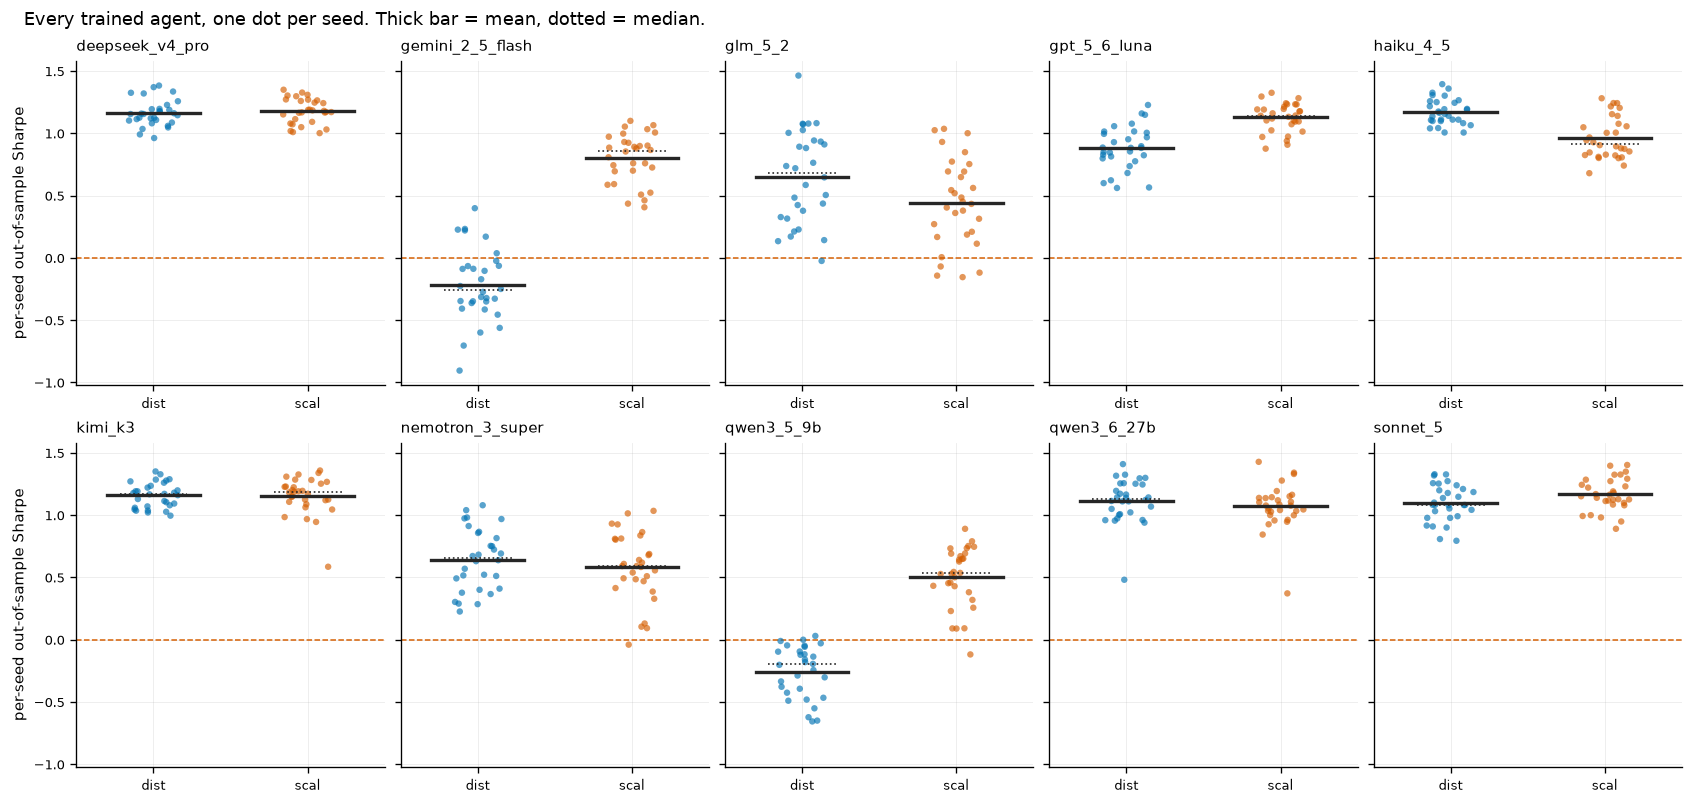

mean    std     min    max  range
model            arm                                                
deepseek_v4_pro  distributional  1.1627 0.1060  0.9620 1.3833 0.4213
                 scalar          1.1781 0.1011  1.0015 1.3498 0.3483
gemini_2_5_flash distributional -0.2162 0.2955 -0.9047 0.3988 1.3035
                 scalar          0.7988 0.1998  0.4062 1.0999 0.6937
glm_5_2          distributional  0.6516 0.3736 -0.0245 1.4636 1.4882
                 scalar          0.4442 0.3543 -0.1546 1.0360 1.1906
gpt_5_6_luna     distributional  0.8818 0.1720  0.5613 1.2275 0.6662
                 scalar          1.1286 0.1158  0.8767 1.3254 0.4487
haiku_4_5        distributional  1.1716 0.1038  1.0062 1.3946 0.3884
                 scalar          0.9628 0.1677  0.6799 1.2813 0.6014
kimi_k3          distributional  1.1586 0.0999  0.9956 1.3505 0.3549
                 scalar          1.1558 0.1518  0.5855 1.3581 0.7726
nemotron_3_super distributional  0.6434 0.2484  0.2261 1.0793 0.8532
                 scalar          0.5832 0.2743 -0.0399 1.0342 1.0741
qwen3_5_9b       distributional -0.2582 0.2091 -0.6562 0.0300 0.6863
                 scalar          0.5006 0.2447 -0.1184 0.8899 1.0083
qwen3_6_27b      distributional  1.1161 0.1754  0.4811 1.4093 0.9282
                 scalar          1.0703 0.1836  0.3716 1.4277 1.0560
sonnet_5         distributional  1.0986 0.1474  0.7940 1.3280 0.5340
                 scalar          1.1671 0.1304  0.8901 1.4025 0.5124

median across cells of the seed standard deviation : 0.174 Sharpe units
median across cells of the seed RANGE              : 0.690 Sharpe units


In [18]:
fig, axes = plt.subplots(2, 5, figsize=(14.0, 6.6), sharey=True)
rng = np.random.default_rng(7)
for ax, line in zip(axes.ravel(), LEG_ORDER):
    for k, arm in enumerate(H2_ARMS):
        v = cell(line, arm).to_numpy()
        if v.size == 0:
            continue
        x = k + rng.uniform(-0.16, 0.16, v.size)
        ax.scatter(x, v, s=15, color=ARMC[arm], alpha=0.65, edgecolor="none", zorder=3)
        ax.plot([k - 0.3, k + 0.3], [v.mean()] * 2, color="0.15", lw=2.0, zorder=4)
        ax.plot([k - 0.22, k + 0.22], [np.median(v)] * 2, color="0.15", lw=1.0, ls=":", zorder=4)
    ax.axhline(0.0, color=OKABE_ITO["vermillion"], lw=0.9, ls="--")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["dist", "scal"], fontsize=8)
    ax.set_title(pretty(line), loc="left", fontsize=9)
    ax.set_xlim(-0.5, 1.5)
axes[0, 0].set_ylabel("per-seed out-of-sample Sharpe")
axes[1, 0].set_ylabel("per-seed out-of-sample Sharpe")
fig.suptitle("Every trained agent, one dot per seed. Thick bar = mean, dotted = median.",
             x=0.01, ha="left", fontsize=11)
savefig(fig, FIGDIR / "F14_per_seed_spread.png")
plt.show()

sp = (D[D["floor"] & D["is_leg"] & D["arm"].isin(H2_ARMS)]
      .groupby(["model", "arm"])["sharpe"].agg(["mean", "std", "min", "max"]))
sp["range"] = sp["max"] - sp["min"]
display(sp)
print("median across cells of the seed standard deviation : %.3f Sharpe units" % sp["std"].median())
print("median across cells of the seed RANGE              : %.3f Sharpe units" % sp["range"].median())

**Figure 14. Per-seed out-of-sample Sharpe for the two experimental arms on each model.** Every dot
is one fully trained agent. The thick bar is the mean, the dotted bar the median.

**What to conclude, and it is the most important context in this notebook.** The spread within a
single arm is large, often comparable to or larger than the gap between arms. **The same reward
code, trained with a different random seed, produces visibly different out-of-sample performance.**

**This is why every claim here is paired.** Comparing two arms on different seeds would be reading
mostly noise. Comparing them seed by seed removes the shared component, which is the whole reason
the H2 pair test runs both arms in one interleaved array.

**It is also why thirty seeds cannot settle a small effect.** Where the two clouds overlap almost
completely, the mean difference is a small signal inside a large variance, and no amount of careful
presentation changes that. Where the clouds separate cleanly, as on the two failing models, thirty
seeds is ample.

**Mean against median is worth a glance.** Where they diverge, a few extreme seeds are pulling the
mean, which is precisely the situation the registered analysis addresses by using an interquartile
mean instead.

## 15. The pairing, shown directly

**Each point is one seed, plotted as its two arms.** A point below the diagonal is a seed where
tail feedback did worse. This is the raw material of every interval in Part B.

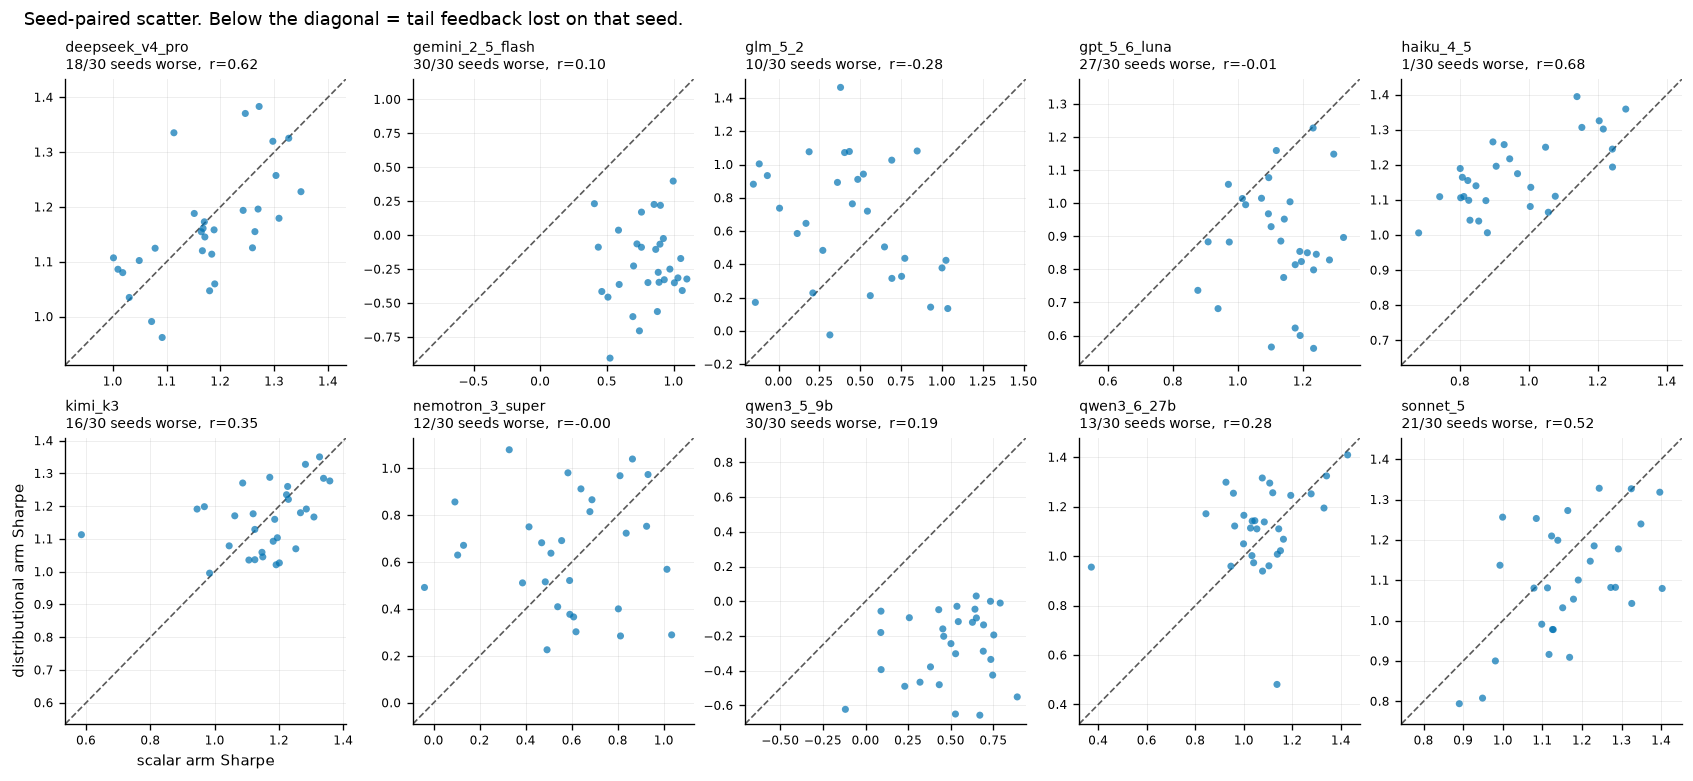

In [19]:
fig, axes = plt.subplots(2, 5, figsize=(14.0, 6.4))
for ax, line in zip(axes.ravel(), LEG_ORDER):
    dd, ds = cell(line, "distributional"), cell(line, "scalar")
    common = dd.index.intersection(ds.index)
    x, y = ds.loc[common].to_numpy(), dd.loc[common].to_numpy()
    below = int((y < x).sum())
    ax.scatter(x, y, s=18, color=OKABE_ITO["blue"], alpha=0.7, edgecolor="none", zorder=3)
    lim = [min(x.min(), y.min()) - 0.05, max(x.max(), y.max()) + 0.05]
    ax.plot(lim, lim, color="0.35", lw=1.0, ls="--", zorder=2)
    ax.set_xlim(lim); ax.set_ylim(lim)
    r = float(np.corrcoef(x, y)[0, 1]) if len(x) > 2 else float("nan")
    ax.set_title("%s\n%d/%d seeds worse,  r=%.2f" % (pretty(line), below, len(x), r),
                 loc="left", fontsize=8.5)
    ax.tick_params(labelsize=7)
axes[1, 0].set_xlabel("scalar arm Sharpe"); axes[1, 0].set_ylabel("distributional arm Sharpe")
fig.suptitle("Seed-paired scatter. Below the diagonal = tail feedback lost on that seed.",
             x=0.01, ha="left", fontsize=11)
savefig(fig, FIGDIR / "F15_paired_scatter.png")
plt.show()

**Figure 15. The two arms plotted against each other, one point per seed, with the equality line.**
Each title reports how many seeds fell below the line and the correlation between the arms.

**What to conclude.** Where the effect is real, almost every seed falls on the same side of the
diagonal. That consistency is far more convincing than a mean difference, because it cannot be
produced by one or two extreme runs.

**The correlation in each title is doing quiet but important work.** Pairing helps when the two arms
move together across seeds, since the shared component cancels. Several of these correlations are
weak or negative, which means **pairing buys less precision here than the design hoped**. That is
not a flaw in the analysis. It is a measured property of the system and it is quantified next.

## 16. Why thirty seeds is not enough, quantified

**The precision of this experiment is set by an arithmetic relation, and every term in it is
measurable.** For a paired difference between two arms,

$$\sigma_D^2 \;=\; \sigma_a^2 + \sigma_b^2 - 2\rho\,\sigma_a\sigma_b$$

where the sigmas are seed-to-seed standard deviations and rho is the correlation between the arms
across seeds. **Pairing only helps when rho is positive.** If the arms are uncorrelated the noise on
the difference is larger than the noise on either arm alone.

,model,n,sigma_dist,sigma_scal,rho,sigma_D,sigma_D_if_rho_0,MDE_at_n,n_for_SESOI_0.05
0,deepseek_v4_pro,30,0.1060,0.1011,0.6219,0.0902,0.1465,0.0542,36
4,haiku_4_5,30,0.1038,0.1677,0.6764,0.1239,0.1972,0.0744,67
9,sonnet_5,30,0.1474,0.1304,0.5206,0.1368,0.1968,0.0822,82
5,kimi_k3,30,0.0999,0.1518,0.3547,0.1493,0.1818,0.0897,97
3,gpt_5_6_luna,30,0.1720,0.1158,-0.0055,0.2078,0.2073,0.1248,188
8,qwen3_6_27b,30,0.1754,0.1836,0.2753,0.2162,0.2539,0.1299,203
7,qwen3_5_9b,30,0.2091,0.2447,0.1862,0.2908,0.3219,0.1746,367
1,gemini_2_5_flash,30,0.2955,0.1998,0.0965,0.3403,0.3567,0.2044,502
6,nemotron_3_super,30,0.2484,0.2743,-0.0003,0.3701,0.3701,0.2223,594
2,glm_5_2,30,0.3736,0.3543,-0.2782,0.5820,0.5149,0.3496,1467


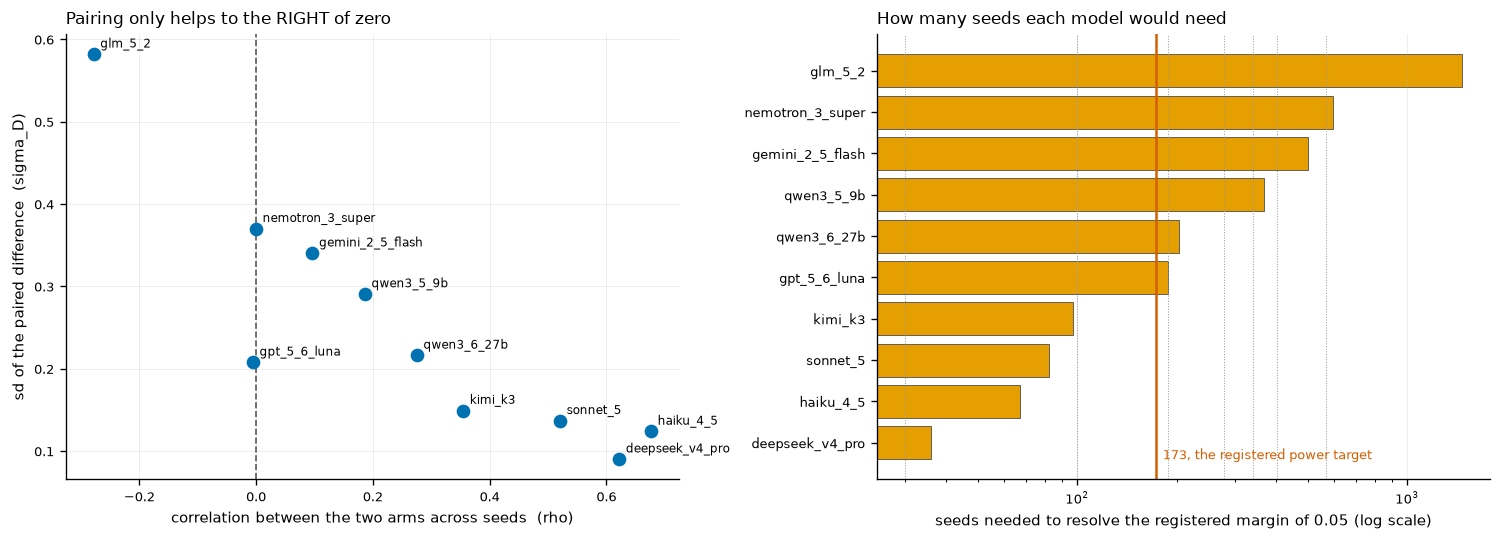

median rho across models           : +0.231   (range -0.278 to +0.676)
median sigma_D                     : 0.212 Sharpe units
median seeds needed for SESOI 0.05 : 195

pairing REDUCED the noise on 7 of 10 models; it INCREASED it on 3
PILOT COMPARISON (docs record sigma_seed=0.244, sigma_D=0.369, rho=-0.14 before launch):
   campaign median sigma_D = 0.212  vs pilot 0.369   -> the pilot OVERSTATED the noise
   campaign median rho     = +0.231 vs pilot -0.14   -> the pilot's NEGATIVE rho did NOT reproduce


In [20]:
dec = []
for line in LEGS:
    dd, ds = cell(line, "distributional"), cell(line, "scalar")
    common = dd.index.intersection(ds.index)
    if len(common) < 5:
        continue
    a, b = dd.loc[common].to_numpy(), ds.loc[common].to_numpy()
    d = a - b
    sa, sb, sd_ = a.std(ddof=1), b.std(ddof=1), d.std(ddof=1)
    rho = float(np.corrcoef(a, b)[0, 1])
    mde = 1.645 * sd_ / np.sqrt(len(common)) * 2      # rough two-sided 90% detectable difference
    dec.append({"model": pretty(line), "n": len(common), "sigma_dist": sa, "sigma_scal": sb,
                "rho": rho, "sigma_D": sd_,
                "sigma_D_if_rho_0": float(np.sqrt(sa ** 2 + sb ** 2)),
                "MDE_at_n": mde,
                "n_for_SESOI_0.05": int(np.ceil((2 * 1.645 * sd_ / 0.05) ** 2))})
DEC = pd.DataFrame(dec).sort_values("sigma_D")
display(DEC)

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.4))
ax = axes[0]
ax.scatter(DEC["rho"], DEC["sigma_D"], s=52, color=OKABE_ITO["blue"], zorder=3)
for _, r in DEC.iterrows():
    ax.annotate(r["model"], (r["rho"], r["sigma_D"]), fontsize=7,
                xytext=(4, 4), textcoords="offset points")
ax.axvline(0.0, color="0.35", ls="--", lw=1.0)
ax.set_xlabel("correlation between the two arms across seeds  (rho)")
ax.set_ylabel("sd of the paired difference  (sigma_D)")
ax.set_title("Pairing only helps to the RIGHT of zero", loc="left")

ax = axes[1]
y = np.arange(len(DEC))
ax.barh(y, DEC["n_for_SESOI_0.05"], color=OKABE_ITO["orange"], edgecolor="0.3", linewidth=0.5)
for r in LADDER:
    ax.axvline(r, color="0.6", lw=0.6, ls=":")
ax.axvline(173, color=OKABE_ITO["vermillion"], lw=1.5)
ax.text(173 * 1.05, -0.4, "173, the registered power target", color=OKABE_ITO["vermillion"], fontsize=7.5)
ax.set_yticks(y); ax.set_yticklabels(DEC["model"], fontsize=8)
ax.set_xscale("log")
ax.set_xlabel("seeds needed to resolve the registered margin of 0.05 (log scale)")
ax.set_title("How many seeds each model would need", loc="left")
ax.grid(axis="y", visible=False)
savefig(fig, FIGDIR / "F16_noise_decomposition.png")
plt.show()

helps = int((DEC["sigma_D"] < DEC["sigma_D_if_rho_0"]).sum())
print("median rho across models           : %+0.3f   (range %+0.3f to %+0.3f)"
      % (DEC["rho"].median(), DEC["rho"].min(), DEC["rho"].max()))
print("median sigma_D                     : %0.3f Sharpe units" % DEC["sigma_D"].median())
print("median seeds needed for SESOI 0.05 : %d" % int(DEC["n_for_SESOI_0.05"].median()))
print()
print("pairing REDUCED the noise on %d of %d models; it INCREASED it on %d"
      % (helps, len(DEC), len(DEC) - helps))
print("PILOT COMPARISON (docs record sigma_seed=0.244, sigma_D=0.369, rho=-0.14 before launch):")
print("   campaign median sigma_D = %.3f  vs pilot 0.369   -> the pilot OVERSTATED the noise"
      % DEC["sigma_D"].median())
print("   campaign median rho     = %+.3f vs pilot -0.14   -> the pilot's NEGATIVE rho did NOT reproduce"
      % DEC["rho"].median())

**Figure 16. Left, the arm-to-arm correlation against the noise on the paired difference. Right, the
number of seeds each model would need to resolve the registered margin.**

**What to conclude, and it corrects a number this project has been carrying since before launch.**

**The correlations are mostly positive and highly heterogeneous**, running from about minus 0.28 to
plus 0.68. Pairing reduces the noise on most models and increases it on a minority, which is exactly
what the formula predicts once rho is allowed to differ by model.

⚠ **The pilot's headline noise figures did not reproduce.** The pre-launch pilot recorded a paired
noise of 0.369 Sharpe units and a *negative* correlation of minus 0.14, and that pair of numbers has
been quoted throughout this project as the reason equivalence would be unreachable. The campaign
measures a median paired noise of about 0.21 and a median correlation that is clearly **positive**.
**The pilot was pessimistic, on a small sample, and the campaign is the better estimate.** Saying so
plainly is worth more than quoting the familiar number.

**The practical consequence cuts the other way from the pessimism, but not far enough.** Lower noise
means fewer seeds are needed than the pilot implied. The seeds required to resolve the registered
margin of 0.05 still run into the hundreds on most models, so **thirty cannot do it, and the upper
rungs of the ladder are where equivalence becomes decidable.** The ladder exists precisely because
nobody could promise in advance which rung would be reached.

**It also reframes what a null would mean at the floor.** A non-rejection at thirty seeds is not
evidence of absence, it is absence of resolution. The registered analysis distinguishes those two
with an explicit inconclusive branch, which is the correct treatment and is worth stating plainly
rather than hoping a reader infers it.

## 17. Does the estimate settle, or is it an artefact of where we stopped?

**The ladder is cumulative and paired, so every prefix of seeds is itself a complete valid study.**
Most published work cannot show this.

**Three disciplines apply and none is optional.** Seeds appear in the registered order and are never
sorted, because sorting would make the curve a selection artefact. The stopping rule is exogenous
and fixed by calendar. **No inference was drawn at any prefix.** Without all three this exhibit
would invite exactly the optional-stopping reasoning the pre-registration forbids.

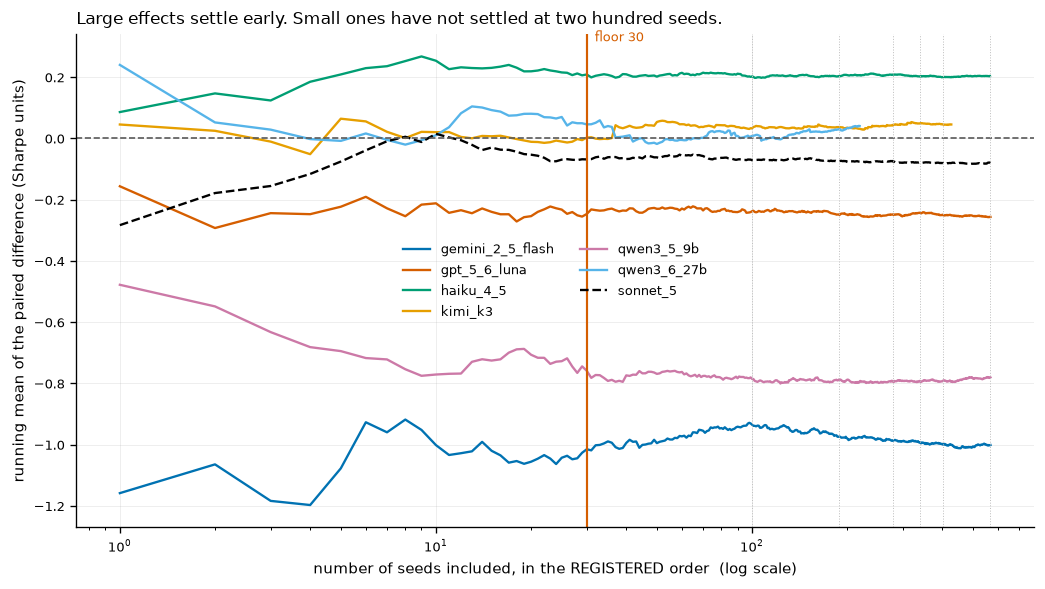

,model,n,at_30,at_full,drift,width_30,width_full,shrink,sign_flips_after_floor
0,gemini_2_5_flash,568,-1.0150,-1.0012,0.0138,0.1984,0.0478,4.1457,False
1,gpt_5_6_luna,568,-0.2467,-0.2565,-0.0097,0.1217,0.0303,4.0152,False
2,haiku_4_5,566,0.2088,0.2034,-0.0054,0.0733,0.0197,3.7246,False
3,kimi_k3,427,0.0028,0.0456,0.0428,0.0875,0.0344,2.5409,True
4,qwen3_5_9b,568,-0.7587,-0.7803,-0.0216,0.1695,0.0426,3.9786,False
5,qwen3_6_27b,219,0.0458,0.0405,-0.0052,0.1268,0.0656,1.9321,True
6,sonnet_5,568,-0.0685,-0.0793,-0.0108,0.0799,0.0183,4.3572,False


In [21]:
DEEP = [l for l in LEGS
        if min(len(cell(l, "distributional", floor_only=False)),
               len(cell(l, "scalar", floor_only=False))) >= 200]

SERIES_STYLE = [(OKABE_ITO["blue"], "-"), (OKABE_ITO["vermillion"], "-"), (OKABE_ITO["green"], "-"),
                (OKABE_ITO["orange"], "-"), (OKABE_ITO["purple"], "-"), (OKABE_ITO["skyblue"], "-"),
                (OKABE_ITO["black"], "--"), (OKABE_ITO["grey"], "--")]
assert len(SERIES_STYLE) >= len(DEEP), "extend SERIES_STYLE"

fig, ax = plt.subplots(figsize=(8.6, 4.8))
traj = []
for k, line in enumerate(sorted(DEEP)):
    dd = cell(line, "distributional", floor_only=False)
    ds = cell(line, "scalar", floor_only=False)
    common = dd.index.intersection(ds.index)                  # REGISTERED ORDER, never value-sorted
    d = (dd.loc[common] - ds.loc[common]).to_numpy()
    run = np.cumsum(d) / np.arange(1, d.size + 1)
    col, sty = SERIES_STYLE[k]
    ax.plot(np.arange(1, d.size + 1), run, lw=1.4, color=col, ls=sty, label=pretty(line))
    _, l30, h30 = boot_ci(d[:FLOOR]); _, lN, hN = boot_ci(d)
    traj.append({"model": pretty(line), "n": d.size, "at_30": d[:FLOOR].mean(), "at_full": d.mean(),
                 "drift": d.mean() - d[:FLOOR].mean(), "width_30": h30 - l30, "width_full": hN - lN,
                 "shrink": (h30 - l30) / (hN - lN) if hN > lN else np.nan,
                 "sign_flips_after_floor": len(set(np.sign(run[FLOOR - 1:]))) > 1})
ax.axhline(0.0, color="0.35", lw=1.0, ls="--")
for r in LADDER:
    ax.axvline(r, color="0.75", lw=0.6, ls=":")
ax.axvline(FLOOR, color=OKABE_ITO["vermillion"], lw=1.3)
ax.text(FLOOR * 1.06, ax.get_ylim()[1] * 0.93, "floor 30", color=OKABE_ITO["vermillion"], fontsize=8)
ax.set_xscale("log")
ax.set_xlabel("number of seeds included, in the REGISTERED order  (log scale)")
ax.set_ylabel("running mean of the paired difference (Sharpe units)")
ax.set_title("Large effects settle early. Small ones have not settled at two hundred seeds.", loc="left")
ax.legend(loc="best", ncols=2, fontsize=8)
savefig(fig, FIGDIR / "F17_seed_trajectory.png")
plt.show()
display(pd.DataFrame(traj))

**Figure 17. Running estimate of the paired difference against the number of seeds included.** Each
curve is the mean of the first n paired differences in registered order.

**What to conclude, and it is more precise than the obvious reading.** Left of about ten seeds every
curve swings violently. By the floor the large effects have found their level, and the table
confirms it: their point estimates move by only a few hundredths of a Sharpe unit between thirty
seeds and full depth.

**So the naive lesson is the wrong one.** It would be easy to look at this and say thirty seeds is
too few. For a large effect it is not, because the wild region ends before the floor begins.

**The real cost of stopping early is precision, not accuracy.** Interval widths shrink by roughly a
factor of four between thirty seeds and full depth, and the registered margin is 0.05, so most
intervals at the floor are wider than the thing they must resolve. **Climbing the ladder buys
precision, and precision is what the registered test consumes.**

**The sharpest point is in the last column.** The models whose running estimate still changes sign
after the floor are exactly the ones whose thirty-seed verdict was no detectable difference. For
those, the *sign* is unsettled well past a hundred seeds. Stability is a property of the effect size
relative to the noise, not of the seed count alone.

# Part C. Mechanism: why the numbers came out this way

A result without an account of it is a measurement waiting to be explained. This part asks what the
agents were actually doing differently.

## 18. Trading costs are the dominant mechanism on the Opus line

**The environment charges a cost on every rebalance, and that cost is large enough to decide the
ranking.** This section tests a specific hypothesis raised by the benchmark table: that the ten
losing human objectives lose because they trade too much, and the one winning objective wins
because it does not.

The test is direct, because every record stores both the net return series and the gross series
before costs.

,sharpe,sharpe_gross,turnover,cost_drag,cost_share,ann_return,kind,label
arm,,,,,,,,
baseline_return_minus_turnover,1.1609,1.1751,0.0077,0.0000,0.0124,0.1574,human canon,return_minus_turnover
scalar_cvar5,1.1558,1.1951,0.0214,0.0000,0.0338,0.1580,LLM designer,scalar_cvar5
placebo,1.1454,1.1700,0.0129,0.0000,0.0215,0.1522,LLM designer,placebo
scalar,1.1354,1.1860,0.0284,0.0000,0.0433,0.1614,LLM designer,scalar
placebo_shuffled,1.1047,1.1640,0.0328,0.0000,0.0515,0.1542,LLM designer,placebo_shuffled
distributional,1.0527,1.1733,0.0570,0.0001,0.1054,0.1257,LLM designer,distributional
bayes_opt,1.0503,1.1208,0.0333,0.0000,0.0633,0.1248,optimiser,bayes_opt
random_search,0.9203,1.0859,0.0739,0.0001,0.1555,0.1044,optimiser,random_search
tpe,0.8876,1.1176,0.1228,0.0001,0.2132,0.1181,optimiser,tpe


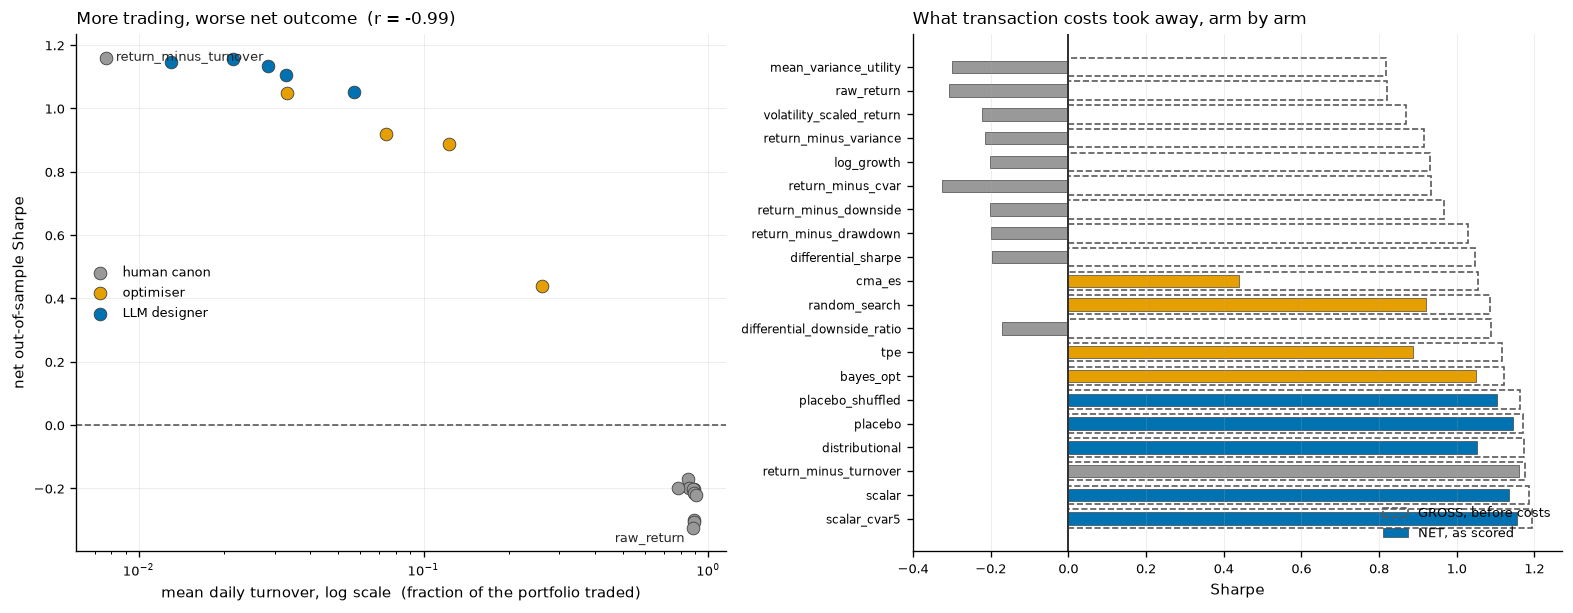

correlation across arms, turnover vs NET Sharpe   : -0.992
correlation across arms, turnover vs GROSS Sharpe : -0.864

mean share of GROSS return consumed by costs: 75.0%

THE HUMAN CANON, ranked by NET Sharpe, with turnover and the gross figure:
   objective                             net  turnover      GROSS
   return_minus_turnover              +1.161     0.008     +1.175
   differential_downside_ratio        -0.171     0.852     +1.088
   differential_sharpe                -0.197     0.853     +1.046
   return_minus_drawdown              -0.199     0.780     +1.028
   log_growth                         -0.201     0.895     +0.932
   return_minus_downside              -0.202     0.884     +0.967
   return_minus_variance              -0.215     0.892     +0.916
   volatility_scaled_return           -0.221     0.907     +0.870
   mean_variance_utility              -0.300     0.893     +0.818
   raw_return                         -0.306     0.893     +0.820
   return_minus_cvar       

In [22]:
O = D[(D["line"] == "test") & D["floor"]].groupby("arm").agg(
    sharpe=("sharpe", "mean"), sharpe_gross=("sharpe_gross", "mean"),
    turnover=("turnover_mean", "mean"), cost_drag=("cost_drag", "mean"),
    cost_share=("cost_share_of_gross", "mean"), ann_return=("ann_return", "mean"))
O["kind"] = ["human canon" if a.startswith("baseline_") else
             "optimiser" if a in DFO_ARMS else "LLM designer" for a in O.index]
O["label"] = [a.replace("baseline_", "") for a in O.index]
display(O.sort_values("sharpe", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.0))
KC = {"human canon": OKABE_ITO["grey"], "optimiser": OKABE_ITO["orange"],
      "LLM designer": OKABE_ITO["blue"]}

ax = axes[0]
for k, c in KC.items():
    s = O[O["kind"] == k]
    ax.scatter(s["turnover"], s["sharpe"], s=58, color=c, label=k, edgecolor="0.25",
               linewidth=0.5, zorder=3)
# LOG x, because turnover spans two orders of magnitude and a linear axis piles the
# low-turnover arms on top of each other. Only the two ends are labelled: annotating the
# whole cluster made the panel unreadable.
ax.set_xscale("log")
for lab, dx, dy in (("return_minus_turnover", 6, -2), ("raw_return", -6, -12)):
    if lab in set(O["label"]):
        r = O[O["label"] == lab].iloc[0]
        ax.annotate(lab, (r["turnover"], r["sharpe"]), fontsize=7.5,
                    xytext=(dx, dy), textcoords="offset points",
                    ha="left" if dx > 0 else "right", color="0.15")
ax.axhline(0.0, color="0.35", lw=1.0, ls="--")
ax.set_xlabel("mean daily turnover, log scale  (fraction of the portfolio traded)")
ax.set_ylabel("net out-of-sample Sharpe")
ax.set_title("More trading, worse net outcome  (r = %+0.2f)" % O[["turnover", "sharpe"]].corr().iloc[0, 1],
             loc="left")
ax.legend(fontsize=7.5, loc="center left")

ax = axes[1]
srt = O.sort_values("sharpe_gross", ascending=False)
y = np.arange(len(srt))
# GROSS drawn as an OUTLINE, not a grey fill: a grey fill behind a grey canon bar made
# return_minus_turnover unreadable, which is the one arm the panel exists to show.
ax.barh(y, srt["sharpe_gross"], height=0.78, facecolor="none", edgecolor="0.35",
        linewidth=1.0, linestyle="--", label="GROSS, before costs")
ax.barh(y, srt["sharpe"], height=0.52, color=[KC[k] for k in srt["kind"]],
        edgecolor="0.25", linewidth=0.4, label="NET, as scored")
ax.set_yticks(y); ax.set_yticklabels(srt["label"], fontsize=7)
ax.axvline(0.0, color="0.2", lw=1.2)
ax.set_xlabel("Sharpe")
ax.set_title("What transaction costs took away, arm by arm", loc="left")
ax.legend(fontsize=7.5, loc="lower right"); ax.grid(axis="y", visible=False)
savefig(fig, FIGDIR / "F18_turnover_and_cost.png")
plt.show()

r_ts = O[["turnover", "sharpe"]].corr().iloc[0, 1]
print("correlation across arms, turnover vs NET Sharpe   : %+0.3f" % r_ts)
print("correlation across arms, turnover vs GROSS Sharpe : %+0.3f"
      % O[["turnover", "sharpe_gross"]].corr().iloc[0, 1])
print()
print("mean share of GROSS return consumed by costs: %.1f%%" % (100 * O["cost_share"].mean()))
print()
canon = O[O["kind"] == "human canon"].sort_values("sharpe", ascending=False)
print("THE HUMAN CANON, ranked by NET Sharpe, with turnover and the gross figure:")
print("   %-32s %8s %9s %10s" % ("objective", "net", "turnover", "GROSS"))
for a, r in canon.iterrows():
    print("   %-32s %+8.3f %9.3f %+10.3f" % (r["label"], r["sharpe"], r["turnover"], r["sharpe_gross"]))
print()
print("   canon arms with POSITIVE gross Sharpe : %d of %d" % ((canon["sharpe_gross"] > 0).sum(), len(canon)))
print("   canon arms with POSITIVE net Sharpe   : %d of %d" % ((canon["sharpe"] > 0).sum(), len(canon)))
print("   turnover of the one profitable arm    : %.3f" % canon["turnover"].min())
print("   median turnover of the other ten      : %.3f"
      % canon.loc[canon["turnover"] > canon["turnover"].min(), "turnover"].median())

**Figure 18. Left, turnover against net Sharpe for every arm on the Opus line. Right, gross Sharpe
behind net Sharpe, so the pale bar is what transaction costs removed.**

**What to conclude, and it is close to deterministic rather than merely suggestive.** Across arms,
turnover and net Sharpe correlate at about minus 0.99. On this line, **knowing how much an arm
trades is very nearly enough to know how it scored.**

### The single most quotable result in this notebook

**Every one of the eleven human-written objectives earns a positive Sharpe before costs. Ten of
them go negative after costs.** They are not bad strategies. They are strategies whose objective
never told them that trading is expensive, so they turn over close to ninety per cent of the
portfolio every day and hand the entire gross return to the transaction-cost model.

**The exception proves the mechanism rather than breaking it.** `return_minus_turnover` is the only
one of the eleven that penalises trading. Its turnover is about a hundredth of the others'. It is
the single best arm on the panel, and its gross and net figures are almost identical because there
is nearly nothing to take away.

**This rewrites how H1 should be described.** The honest claim is not that a language model writes
better objectives than a person in some general sense. It is that **ten of eleven published
objectives, implemented exactly as written, do not price transaction costs, and every automated
designer discovered that it must.** That is narrower, far better supported, and much more useful to
a practitioner deciding what to deploy.

**Three cautions before this is over-read.** The relation is a correlation across arms rather than a
controlled manipulation. The cost model is linear and fixed by configuration, so the entire grid
could be repriced at a different cost level **without retraining anything**, and that sensitivity
sweep is the obvious next analysis and is not run here. And the canon objectives were implemented
faithfully to their sources, which mostly predate this cost regime, so this is a statement about
transplanting them unmodified rather than about their authors.

## 19. What the portfolios looked like

**Turnover says how much the agent traded. Concentration says how much it bet on any one thing.**
Both are choices the reward makes, and neither is scored directly.

exp_eff_n  exp_hhi  exp_max_weight  exp_top5  turnover_mean
model            arm                                                                          
deepseek_v4_pro  distributional      11.0911   0.0910          0.0929    0.4622         0.0103
                 placebo             13.5262   0.0745          0.0760    0.3779         0.0073
                 placebo_shuffled    11.2027   0.0919          0.0977    0.4709         0.0211
                 scalar              12.6845   0.0797          0.0811    0.4032         0.0076
                 scalar_cvar5        13.6542   0.0749          0.0789    0.3910         0.0141
gemini_2_5_flash distributional       3.5746   0.3786          0.4855    0.9392         0.8891
                 placebo              9.5738   0.1137          0.1383    0.5938         0.1858
                 placebo_shuffled     9.9399   0.1055          0.1407    0.6000         0.3659
                 scalar               9.8382   0.1048          0.1276    0.5887         0.2161
                 scalar_cvar5        10.2052   0.1035          0.1126    0.5235         0.0318
glm_5_2          distributional       9.7767   0.1069          0.1334    0.5893         0.2858
                 placebo             13.0423   0.0774          0.0786    0.3911         0.0067
                 placebo_shuffled     9.6273   0.1093          0.1321    0.5989         0.1969
                 scalar               8.9049   0.1244          0.1695    0.6639         0.4052
                 scalar_cvar5        13.4989   0.0749          0.0769    0.3823         0.0095
gpt_5_6_luna     distributional      10.1098   0.1071          0.1280    0.5563         0.1407
                 placebo             11.5270   0.0877          0.0923    0.4529         0.0235
                 placebo_shuffled    16.4576   0.0612          0.0658    0.3231         0.0204
                 scalar              12.2250   0.0844          0.0885    0.4289         0.0136
                 scalar_cvar5        10.7346   0.0979          0.1023    0.4925         0.0154
haiku_4_5        distributional      13.8278   0.0730          0.0745    0.3706         0.0076
                 placebo             16.0807   0.0624          0.0646    0.3209         0.0093
                 placebo_shuffled    11.9149   0.0872          0.0963    0.4635         0.0541
                 scalar              10.7424   0.0955          0.1102    0.5179         0.0844
                 scalar_cvar5        10.9070   0.0937          0.1008    0.4925         0.0451
kimi_k3          distributional      13.3996   0.0752          0.0771    0.3832         0.0088
                 placebo             13.8139   0.0729          0.0750    0.3728         0.0106
                 placebo_shuffled    14.2458   0.0728          0.0892    0.4081         0.0854
                 scalar              12.7126   0.0818          0.0840    0.4159         0.0129
                 scalar_cvar5        10.2104   0.1012          0.1201    0.5615         0.1177
nemotron_3_super distributional      12.8398   0.0807          0.1101    0.4889         0.3030
                 placebo             11.4486   0.0889          0.0898    0.4470         0.0065
                 placebo_shuffled     9.9962   0.1084          0.1477    0.5952         0.2741
                 scalar               7.7956   0.1372          0.1824    0.7345         0.3718
                 scalar_cvar5        10.6691   0.0964          0.1004    0.4914         0.0167
qwen3_5_9b       distributional       6.1827   0.2087          0.2796    0.8224         0.8296
                 placebo             17.6669   0.0569          0.0590    0.2918         0.0059
                 placebo_shuffled     8.3507   0.1289          0.1789    0.7044         0.6320
                 scalar              15.3864   0.0684          0.1049    0.4340         0.3960
                 scalar_cvar5        29.9768   0.0337          0.0400    0.1904         0.0364
qwen3_6_27b      distributional      12.3949 

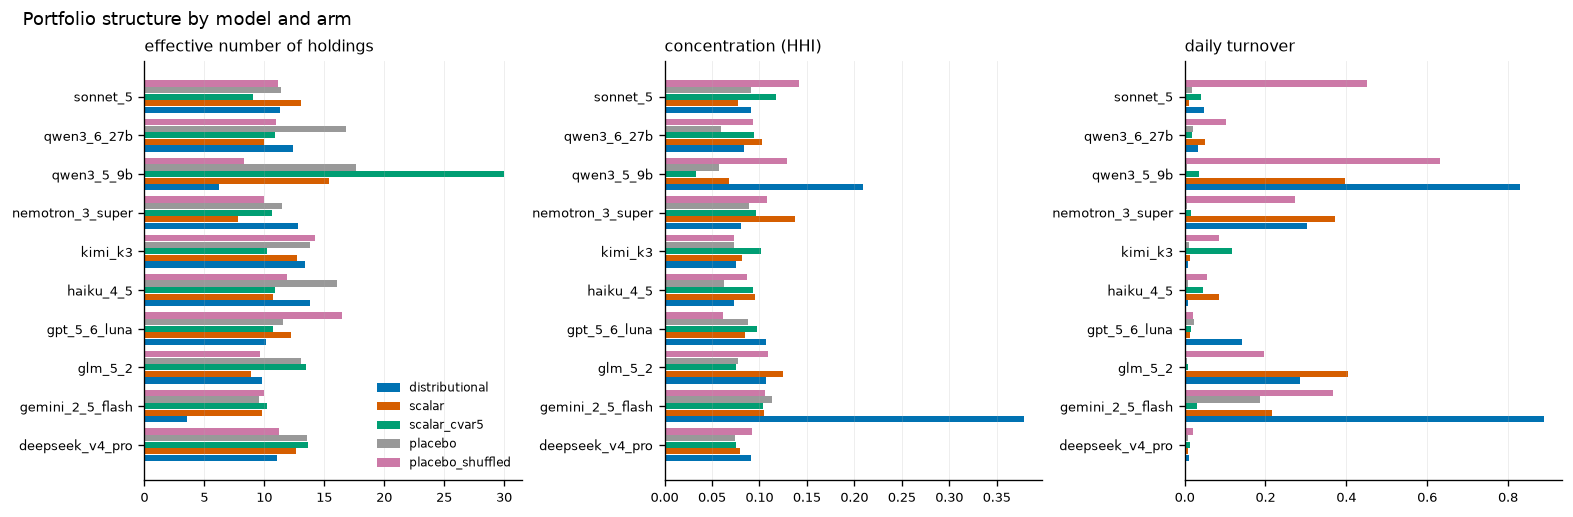

In [23]:
CONC = ["exp_eff_n", "exp_hhi", "exp_max_weight", "exp_top5"]
C = D[D["floor"] & D["is_leg"] & D["arm"].isin(LEG_ARMS)].groupby(["model", "arm"])[
    CONC + ["turnover_mean"]].mean()
display(C.round(4))

fig, axes = plt.subplots(1, 3, figsize=(13.0, 4.2))
for ax, col, name in zip(axes, ["exp_eff_n", "exp_hhi", "turnover_mean"],
                         ["effective number of holdings", "concentration (HHI)", "daily turnover"]):
    piv = C[col].unstack()[list(LEG_ARMS)]
    y = np.arange(len(piv))
    for i, arm in enumerate(LEG_ARMS):
        ax.barh(y + (i - 2) * 0.17, piv[arm], height=0.16, color=ARMC[arm],
                label=arm if col == "exp_eff_n" else None)
    ax.set_yticks(y); ax.set_yticklabels(piv.index, fontsize=7.5)
    ax.set_title(name, loc="left", fontsize=9.5)
    ax.grid(axis="y", visible=False)
axes[0].legend(fontsize=7, loc="lower right")
fig.suptitle("Portfolio structure by model and arm", x=0.01, ha="left", fontsize=11)
savefig(fig, FIGDIR / "F19_concentration.png")
plt.show()

**Figure 19. Effective number of holdings, concentration and turnover, by model and arm.** A higher
effective number means a more spread portfolio, a higher HHI a more concentrated one.

**What to conclude.** Portfolio structure is remarkably stable across arms within a model. The
reward changes *how much the agent trades* far more than *what it holds*. That is a meaningful
constraint on any mechanism story: whatever tail feedback did, it did not mainly work by pushing
the agent into a different kind of portfolio.

**Where structure does move it moves together with turnover**, which is consistent with the cost
mechanism of the previous section rather than being an independent effect.

## 20. Learning dynamics

**Did the different rewards produce different training, or the same training scored differently?**

⚠ A gap, reported rather than hidden. `train_curve["return"]` is NaN in every record, so the rollout
return during training was never captured. The loss curves are populated and are shown here
instead. **This is a real limitation of the archive**, and it means training progress cannot be
plotted in reward units.

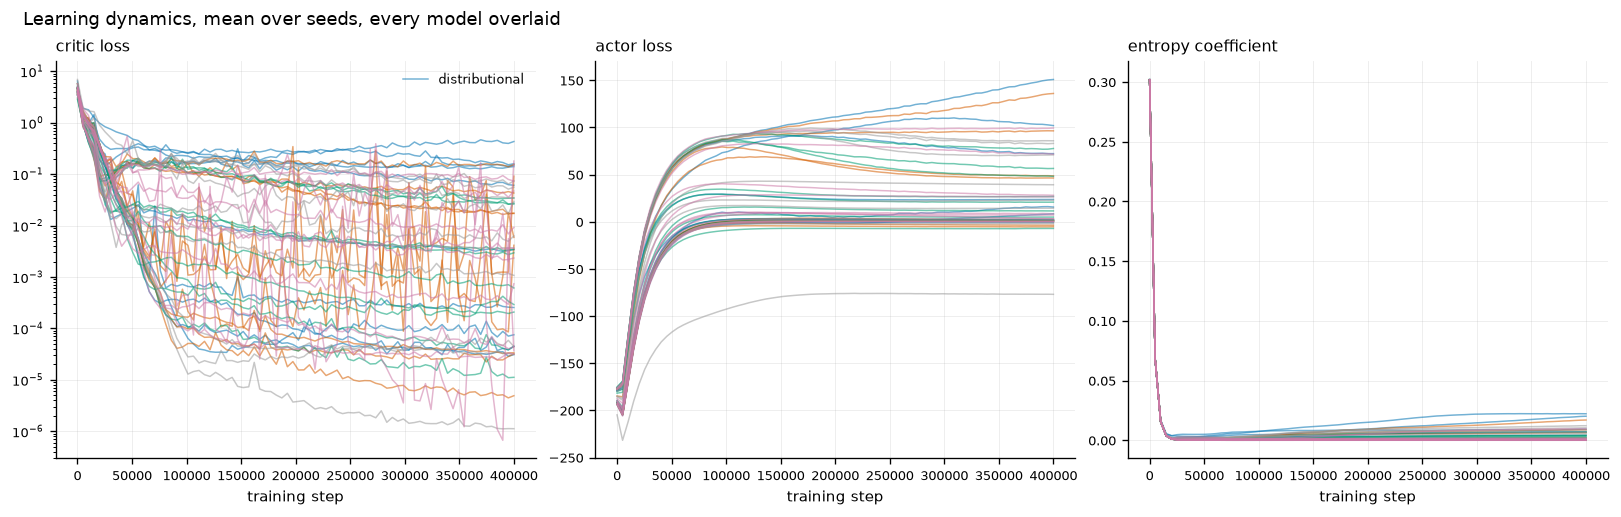

,train_critic_loss_final,train_actor_loss_final,train_ent_coef_final,safe_default_rate
arm,,,,
distributional,0.0944,37.7241,0.0070,0.0079
scalar,0.0333,32.2545,0.0036,0.0000
scalar_cvar5,0.0095,24.3571,0.0023,0.0000
placebo,0.0204,23.8555,0.0047,0.0000
placebo_shuffled,0.0316,24.8088,0.0015,0.0091


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(13.4, 4.2))
for ax, field, name in zip(axes, ["tc_critic_loss", "tc_actor_loss", "tc_ent_coef"],
                           ["critic loss", "actor loss", "entropy coefficient"]):
    drawn = 0
    for arm in LEG_ARMS:
        for k, line in enumerate(LEG_ORDER):
            v = S(line, arm, field)
            if v is None:
                continue
            ax.plot(np.linspace(0, 400_000, v.size), v, lw=0.9, alpha=0.55, color=ARMC[arm],
                    label=arm if (k == 0 and drawn == 0) else None)
        drawn = 1
    ax.set_xlabel("training step"); ax.set_title(name, loc="left", fontsize=9.5)
    if field == "tc_critic_loss":
        ax.set_yscale("log"); ax.legend(fontsize=7.5)
fig.suptitle("Learning dynamics, mean over seeds, every model overlaid", x=0.01, ha="left", fontsize=11)
savefig(fig, FIGDIR / "F20_learning_dynamics.png")
plt.show()

display(D[D["floor"] & D["is_leg"] & D["arm"].isin(LEG_ARMS)]
        .groupby("arm")[["train_critic_loss_final", "train_actor_loss_final",
                         "train_ent_coef_final", "safe_default_rate"]].mean().loc[list(LEG_ARMS)])

**Figure 20. Critic loss, actor loss and the entropy coefficient through training, averaged over
seeds and overlaid across models.**

**What to conclude.** Every run converges. Critic loss falls by three or more orders of magnitude
and the entropy coefficient decays as the policy sharpens, which is the expected signature of Soft
Actor-Critic training successfully. **No arm shows a pathology that would explain its outcome as a
training failure**, and that matters, because it rules out the simplest alternative explanation for
the two failing models: they did not fail to train, they trained successfully on a worse objective.

**The actor loss is not comparable across arms and should not be read as quality.** It is computed
against the arm's own reward scale, so an arm with a larger-magnitude reward shows a larger loss
without being worse. This is exactly the kind of number that looks like a result and is not one.

## 21. The authored reward programs themselves

**The object the language model actually produced is a piece of code, and it is archived.** This
section reports its measurable properties and one safety statistic that bears directly on the
mechanism story.

In [25]:
PG = D[D["floor"] & D["arm"].isin(LEG_ARMS)].groupby(["model", "arm"]).agg(
    distinct_rewards=("reward_hash", "nunique"),
    reward_chars=("reward_chars", "mean"),
    default_rate=("safe_default_rate", "mean"))
display(PG.round(5))

tot_calls = int(D["safe_calls"].fillna(0).sum())
tot_def = int(D["safe_defaults"].fillna(0).sum())
print("ACROSS THE WHOLE ARCHIVE")
print("   reward-function calls inside training               : {:,}".format(tot_calls))
print("   times the sandbox had to substitute a default value : {:,}".format(tot_def))
print("   overall fallback rate : %.4f%%" % (100.0 * tot_def / tot_calls if tot_calls else float("nan")))
print()

byc = D[D["floor"]].groupby(["model", "arm"])["safe_default_rate"].mean()
nz = byc[byc > 1e-9].sort_values(ascending=False)
print("WHERE THE FALLBACKS ARE. Cells with ANY fallback: %d of %d" % (len(nz), byc.size))
for (mdl, arm), v in nz.items():
    print("   %-22s %-20s %7.4f%%" % (mdl, arm, 100 * v))
print()
print("the same models' OTHER arms, for contrast:")
for mdl in nz.index.get_level_values(0).unique():
    for arm in LEG_ARMS:
        if (mdl, arm) in byc.index:
            print("   %-22s %-20s %7.4f%%" % (mdl, arm, 100 * byc.loc[(mdl, arm)]))
print()
print("distinct reward programs per (model, arm): min %d, max %d"
      % (PG["distinct_rewards"].min(), PG["distinct_rewards"].max()))
print("   (a frozen winner is ONE program run on many seeds, so 1 is the CORRECT value)")

distinct_rewards  reward_chars  default_rate
model            arm                                                           
OPUS 5           distributional                   1     4690.0000        0.0000
                 placebo                          1     4063.0000        0.0000
                 placebo_shuffled                 1     4776.0000        0.0000
                 scalar                           1     4761.0000        0.0000
                 scalar_cvar5                     1     4150.0000        0.0000
deepseek_v4_pro  distributional                   1     2669.0000        0.0000
                 placebo                          1     3025.0000        0.0000
                 placebo_shuffled                 1     3223.0000        0.0000
                 scalar                           1     2617.0000        0.0000
                 scalar_cvar5                     1     2705.0000        0.0000
gemini_2_5_flash distributional                   1     6327.0000        0.0000
                 placebo                          1     1810.0000        0.0000
                 placebo_shuffled                 1     3355.0000        0.0000
                 scalar                           1     2192.0000        0.0000
                 scalar_cvar5                     1     4838.0000        0.0000
glm_5_2          distributional                   1     2757.0000        0.0000
                 placebo                          1     1832.0000        0.0000
                 placebo_shuffled                 1     2485.0000        0.0000
                 scalar                           1     1386.0000        0.0000
                 scalar_cvar5                     1     1824.0000        0.0000
gpt_5_6_luna     distributional                   1     2500.0000        0.0000
                 placebo                          1     1628.0000        0.0000
                 placebo_shuffled                 1     2168.0000        0.0000
                 scalar                           1     1615.0000        0.0000
                 scalar_cvar5                     1     1765.0000        0.0000
h3_singleshot    distributional                   1     3992.0000        0.0000
haiku_4_5        distributional                   1     2763.0000        0.0000
                 placebo                          1     3007.0000        0.0000
                 placebo_shuffled                 1     3804.0000        0.0000
                 scalar                           1     3459.0000        0.0000
                 scalar_cvar5                     1     3385.0000        0.0000
kimi_k3          distributional                   1     3046.0000        0.0000
                 placebo                          1     3096.0000        0.0000
                 placebo_shuffled                 1     2456.0000        0.0000
                 scalar                           1     3762.0000        0.0000
                 scalar_cvar5                     1     1621.0000        0.0000
nemotron_3_super distributional                   1     2176.0000        0.0000
                 placebo                          1     2576.0000        0.0000
                 placebo_shuffled                 1     2820.0000        0.0000
                 scalar                           1     1600.0000        0.0000
                 scalar_cvar5                     1     2953.0000        0.0000
qwen3_5_9b       distributional                   1     4428.0000        0.0785
                 placebo                          1     6398.0000        0.0000
                 placebo_shuffled                 1     6990.0000        0.0909
                 scalar                           1     3976.0000        0.0000
                 scalar_cvar5                     1     6325.0000        0.0000
qwen3_6_27b      distributional                   1     5221.0000        0.0000
                 placebo                          1     3790.0000        0.0000
                 placebo_shuffled  

ACROSS THE WHOLE ARCHIVE
   reward-function calls inside training               : 7,688,800,000
   times the sandbox had to substitute a default value : 38,484,068
   overall fallback rate : 0.5005%

WHERE THE FALLBACKS ARE. Cells with ANY fallback: 4 of 71
   qwen3_5_9b             placebo_shuffled      9.0847%
   qwen3_5_9b             distributional        7.8541%
   OPUS 5                 baseline_differential_downside_ratio  0.0000%
   OPUS 5                 baseline_differential_sharpe  0.0000%

the same models' OTHER arms, for contrast:
   qwen3_5_9b             distributional        7.8541%
   qwen3_5_9b             scalar                0.0000%
   qwen3_5_9b             scalar_cvar5          0.0000%
   qwen3_5_9b             placebo               0.0000%
   qwen3_5_9b             placebo_shuffled      9.0847%
   OPUS 5                 distributional        0.0000%
   OPUS 5                 scalar                0.0000%
   OPUS 5                 scalar_cvar5          0.0000%
  

### ★ The clearest mechanism evidence in the whole notebook

**The failing arm is not merely writing worse reward code. It is writing code that crashes.**

The sandbox executes untrusted, model-authored reward code inside the training loop. When that code
raises, the sandbox substitutes a default value and records it. Across the archive the overall
fallback rate is low, and it is **not spread evenly**. Almost every cell is exactly zero.

**The exceptions are `qwen3_5_9b`'s `distributional` and `placebo_shuffled` arms**, at roughly eight
and nine per cent. Its `scalar` arm is zero. So the smallest model in the suite, handed a block of
six tail numbers, wrote reward code that failed on close to one call in twelve, and handed a single
number it wrote code that never failed at all.

**Those are precisely the two arms that failed on that model** in Part B: `distributional` is the
one with negative out-of-sample Sharpe, and `placebo_shuffled` is the weakest control. **The
mechanism is therefore visible rather than inferred**: the structured numeric block induces buggy
code in a model that cannot handle it, the agent trains against a reward that is silently defaulting
a twelfth of the time, and the resulting policy is worse.

**This sharpens the numeracy-bottleneck story into something more specific and more testable.** The
claim is not vaguely that a weak model "does not use" the tail information. It is that the tail
block pushes it into writing code it cannot write correctly.

⚠ **And it does not explain the other failing model.** `gemini_2_5_flash` has a zero fallback rate on
every arm and still produces negative Sharpe under `distributional`. **Two models fail and only one
of them fails this way.** Reporting a single mechanism for both would be tidier and wrong. What
`gemini_2_5_flash` wrote runs perfectly and optimises the wrong thing, which is a different failure
and needs the responsiveness and mediation instruments to diagnose.

**Two smaller points.** One distinct reward program per cell is correct rather than suspicious: the
search selects a winner, the winner is frozen, and every seed trains against that same program. And
program length is reported as the weak proxy it is, since it cannot distinguish an elaborate reward
from a verbose one.

## 22. Search quality: was the winner actually good?

**Every arm got the same budget of thirty candidates.** The validation fitness of the selected
winner is the search's own verdict on itself, before the sealed window was ever touched.

This matters for a specific reason. A sceptic reading a null result will say the search was not run
hard enough. `val_fitness` is the evidence on that question, and it was recorded before any test
data was seen.

arm,distributional,scalar,scalar_cvar5,placebo,placebo_shuffled
model,,,,,
OPUS 5,0.2251,0.2297,0.3002,0.1666,0.2946
deepseek_v4_pro,0.1781,0.2275,0.1103,0.2478,0.3513
gemini_2_5_flash,0.0205,0.1821,0.1706,0.0907,0.2790
glm_5_2,0.4319,0.2704,0.4227,0.1983,0.2042
gpt_5_6_luna,0.2011,0.2761,0.3487,0.2058,0.3006
h3_singleshot,0.2254,NaN,NaN,NaN,NaN
haiku_4_5,0.2696,0.2777,0.3002,0.3118,0.2480
kimi_k3,0.3044,0.2500,0.2794,0.2891,0.2857
nemotron_3_super,0.0766,0.0795,0.2008,0.2254,0.3327


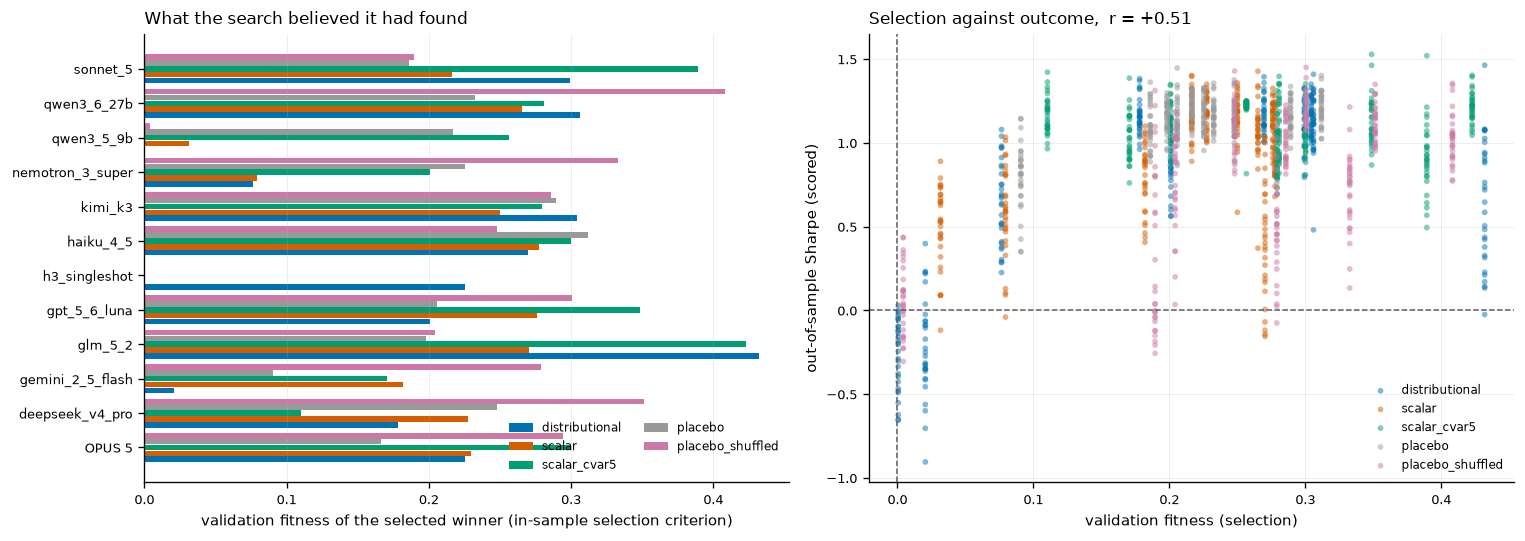

correlation between validation fitness and out-of-sample Sharpe: +0.507


In [26]:
VF = D[D["floor"] & D["arm"].isin(LEG_ARMS)].groupby(["model", "arm"])["val_fitness"].mean().unstack()
VF = VF[list(LEG_ARMS)]
display(VF.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4))
ax = axes[0]
y = np.arange(len(VF))
for i, arm in enumerate(LEG_ARMS):
    ax.barh(y + (i - 2) * 0.17, VF[arm], height=0.16, color=ARMC[arm], label=arm)
ax.set_yticks(y); ax.set_yticklabels(VF.index, fontsize=8)
ax.axvline(0.0, color="0.3", lw=1.0)
ax.set_xlabel("validation fitness of the selected winner (in-sample selection criterion)")
ax.set_title("What the search believed it had found", loc="left")
ax.legend(fontsize=7, ncols=2); ax.grid(axis="y", visible=False)

ax = axes[1]
q = D[D["floor"] & D["arm"].isin(LEG_ARMS) & D["is_leg"]]
for arm in LEG_ARMS:
    s = q[q["arm"] == arm]
    ax.scatter(s["val_fitness"], s["sharpe"], s=12, alpha=0.5, color=ARMC[arm], label=arm,
               edgecolor="none")
ax.axhline(0.0, color="0.35", lw=0.9, ls="--"); ax.axvline(0.0, color="0.35", lw=0.9, ls="--")
ax.set_xlabel("validation fitness (selection)"); ax.set_ylabel("out-of-sample Sharpe (scored)")
r = q[["val_fitness", "sharpe"]].corr().iloc[0, 1]
ax.set_title("Selection against outcome,  r = %+0.2f" % r, loc="left")
ax.legend(fontsize=7)
savefig(fig, FIGDIR / "F22_search_quality.png")
plt.show()
print("correlation between validation fitness and out-of-sample Sharpe: %+0.3f" % r)

**Figure 22. Left, the validation fitness of the winner each search selected. Right, that selection
criterion against the outcome it was supposed to predict.**

**What to conclude, and it defends the study against its most obvious criticism.** Every arm's
search found a winner with positive validation fitness. **No arm failed to search.** A null on the
headline contrast therefore cannot be explained by one arm simply not having tried, which is
exactly the objection a referee raises against a negative result.

**The right panel is a validity check on the whole protocol.** Validation fitness is measured
in-sample on a window the agent trained near, and Sharpe is measured on a sealed window years
later. A positive relation between them says the selection criterion carries real signal rather
than selecting noise. A relation far weaker than expected would be the interesting finding here,
because it would mean the search was optimising something that does not survive out of sample.

**Note what this does not show.** Validation fitness is tail-blind by construction, which is a
deliberate feature of the design: the selection criterion is identical across arms so that only the
feedback channel differs. An arm cannot win by being selected on a different objective.

# Part D. Against the benchmarks

Two registered questions live here. **H1 asks whether the automated designer beats what a person
would write.** **H4 asks whether it beats a conventional optimiser given the same budget.** The
second exists so the first cannot be dismissed as beating a straw man.

## 23. The benchmark ladder

**Ten of the eleven human-written objectives are beaten by every automated arm. The eleventh beats
all of them.**

The eleven baselines are the canon of objectives used in the reinforcement-learning-for-finance
literature, implemented as published. The four optimiser arms search the same reward space with the
same thirty-candidate budget and no language model.

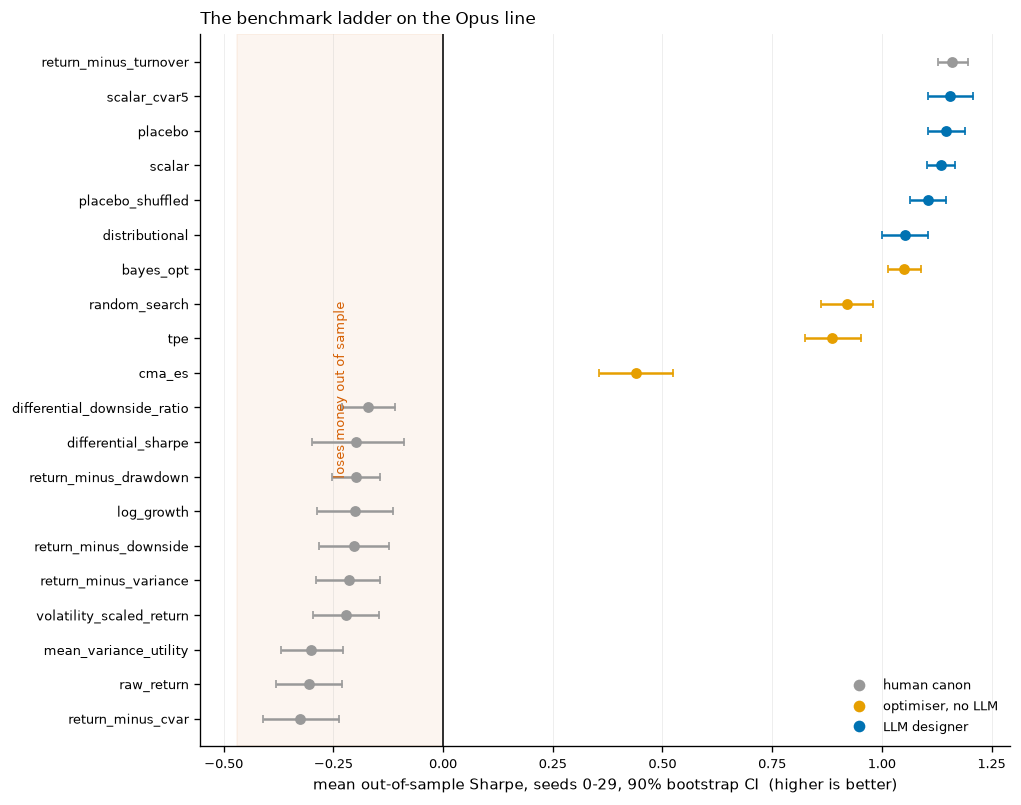

,arm,kind,mean,lo,hi,n
19,return_minus_turnover,human canon,1.1609,1.1286,1.1961,30
18,scalar_cvar5,LLM designer,1.1558,1.1061,1.2083,30
17,placebo,LLM designer,1.1454,1.1053,1.1900,30
16,scalar,LLM designer,1.1354,1.1041,1.1661,30
15,placebo_shuffled,LLM designer,1.1047,1.0640,1.1458,30
14,distributional,LLM designer,1.0527,1.0006,1.1057,30
13,bayes_opt,"optimiser, no LLM",1.0503,1.0131,1.0894,30
12,random_search,"optimiser, no LLM",0.9203,0.8609,0.9794,30
11,tpe,"optimiser, no LLM",0.8876,0.8243,0.9520,30
10,cma_es,"optimiser, no LLM",0.4391,0.3560,0.5241,30


automated arms above zero : 9 of 9
human objectives above zero: 1 of 11


In [27]:
lad = []
for arm in D.loc[D["line"] == "test", "arm"].unique():
    v = cell("test", arm).to_numpy()
    if v.size < 5:
        continue
    m, lo, hi = boot_ci(v)
    kind = ("human canon" if arm.startswith("baseline_") else
            "optimiser, no LLM" if arm in DFO_ARMS else "LLM designer")
    lad.append((arm.replace("baseline_", ""), kind, m, lo, hi, int(v.size)))
lad.sort(key=lambda t: t[2])

KC2 = {"human canon": OKABE_ITO["grey"], "optimiser, no LLM": OKABE_ITO["orange"],
       "LLM designer": OKABE_ITO["blue"]}
fig, ax = plt.subplots(figsize=(8.4, 6.6))
for i, (name, kind, m, lo, hi, n) in enumerate(lad):
    ax.errorbar(m, i, xerr=[[m - lo], [hi - m]], fmt="o", color=KC2[kind], ecolor=KC2[kind],
                elinewidth=1.5, capsize=2.5, markersize=5.5, zorder=3)
ax.axvline(0.0, color="0.2", lw=1.2)
xlo = min(t[3] for t in lad) - 0.06
ax.axvspan(xlo, 0.0, color=OKABE_ITO["vermillion"], alpha=0.06, zorder=0)
ax.text(xlo / 2, (len(lad) - 1) / 2, "loses money out of sample", rotation=90,
        ha="center", va="center", fontsize=8, color=OKABE_ITO["vermillion"])
if not HAS_OPUS:
    ax.text(0.02, len(lad) - 0.5, "distributional and scalar still running",
            fontsize=8.5, style="italic", color=OKABE_ITO["green"])
ax.set_yticks(np.arange(len(lad))); ax.set_yticklabels([t[0] for t in lad])
ax.set_ylim(-0.8, len(lad) - 0.2)
ax.set_xlabel("mean out-of-sample Sharpe, seeds 0-%d, 90%% bootstrap CI  (higher is better)" % (FLOOR - 1))
ax.set_title("The benchmark ladder on the Opus line", loc="left")
ax.legend(handles=[plt.Line2D([], [], marker="o", ls="none", color=c, label=k)
                   for k, c in KC2.items()], loc="lower right", fontsize=8)
ax.grid(axis="y", visible=False)
savefig(fig, FIGDIR / "F23_benchmark_ladder.png")
plt.show()

L = pd.DataFrame(lad, columns=["arm", "kind", "mean", "lo", "hi", "n"]).sort_values("mean", ascending=False)
display(L)
print("automated arms above zero : %d of %d" % ((L[L["kind"] != "human canon"]["mean"] > 0).sum(),
                                                (L["kind"] != "human canon").sum()))
print("human objectives above zero: %d of %d" % ((L[L["kind"] == "human canon"]["mean"] > 0).sum(),
                                                 (L["kind"] == "human canon").sum()))

**Figure 23. Every arm on the Opus line at thirty seeds, ranked, with ninety per cent intervals.**
Grey is a human-written objective, orange a derivative-free optimiser with no language model, blue
a language-model designer.

**What to conclude.** The separation is not marginal. Ten of the eleven human objectives sit below
zero and every automated arm sits well above, with a gap far outside the intervals.

**The one result that does not fit is the most interesting row here.** `return_minus_turnover` is
the best arm on the entire panel while the other ten human objectives are the worst, and Section 18
established why: it is the only one of the eleven that penalises trading, in an environment where
trading is expensive. **That is a mechanism, not a coincidence**, and it makes the H1 claim sharper
and more defensible.

**A second surprise, named rather than smoothed over.** `return_minus_cvar` is last. The objective
built explicitly to control tail loss has neither the best Sharpe nor the best CVaR. That is worth
reporting flatly and investigating.

**The honest limit on this comparison.** The baselines are fixed objectives evaluated once, while
the automated arms are winners of a thirty-candidate search. Part of the gap is selection. **The
optimiser arms exist precisely to price that**, since they get the same budget without a language
model, and they land below the language-model arms but far above the canon. That is the H4 answer
and it is the reason H1 cannot be waved away as an unfair comparison.

# Part E. Controls, the full grid, and the limits

## 24. What the control arms rule out, and one thing they do not

**Three controls sit between the treatment and any causal claim.** They are measured here rather
than eyeballed, and one of them returns an uncomfortable answer.

In [28]:
print("C1. placebo minus scalar   = does MORE TEXT alone help, with no information in it?")
print("%-20s %-28s %s" % ("model", "d Sharpe [90% CI]", "verdict"))
print("-" * 76)
n_help = n_hurt = 0
for line in LEG_ORDER:
    d = paired(line, "placebo", "scalar", "sharpe")
    if d.size < 5:
        continue
    m, lo, hi = boot_ci(d)
    v = "inert block HELPS" if lo > 0 else ("inert block HURTS" if hi < 0 else "no difference")
    n_help += int(lo > 0); n_hurt += int(hi < 0)
    print("%-20s %+7.4f [%+7.4f,%+7.4f]    %s" % (pretty(line), m, lo, hi, v))
print("   -> the inert block significantly HELPED on %d of %d models, HURT on %d"
      % (n_help, len(LEG_ORDER), n_hurt))

print()
print("C2. placebo_shuffled versus the other controls: is deranging the values the WORST option?")
weakest = tot = 0
for line in LEG_ORDER:
    vals = {a: cell(line, a).mean() for a in ("scalar_cvar5", "placebo", "placebo_shuffled")
            if len(cell(line, a)) >= 5}
    if len(vals) < 3:
        continue
    tot += 1
    is_min = min(vals, key=vals.get) == "placebo_shuffled"
    weakest += int(is_min)
    print("   %-20s %s  %s" % (pretty(line),
          "  ".join("%s=%+0.3f" % (k[:12], v) for k, v in vals.items()),
          "<- shuffled weakest" if is_min else ""))
print("   -> deranged values were the weakest control on %d of %d models" % (weakest, tot))

print()
print("C3. scalar_cvar5 minus scalar = does ONE tail number help, without the full shape?")
for line in LEG_ORDER:
    d = paired(line, "scalar_cvar5", "scalar", "sharpe")
    if d.size < 5:
        continue
    m, lo, hi = boot_ci(d)
    print("   %-20s %+7.4f [%+7.4f,%+7.4f]  %s"
          % (pretty(line), m, lo, hi, "DIFFERENT" if lo * hi > 0 else "no difference"))

C1. placebo minus scalar   = does MORE TEXT alone help, with no information in it?
model                d Sharpe [90% CI]            verdict
----------------------------------------------------------------------------
deepseek_v4_pro      -0.0226 [-0.0503,+0.0066]    no difference
gemini_2_5_flash     -0.0028 [-0.0580,+0.0502]    no difference
glm_5_2              +0.7092 [+0.6042,+0.8132]    inert block HELPS
gpt_5_6_luna         -0.0031 [-0.0418,+0.0359]    no difference
haiku_4_5            +0.2444 [+0.2027,+0.2868]    inert block HELPS
kimi_k3              +0.0086 [-0.0313,+0.0512]    no difference
nemotron_3_super     +0.5880 [+0.5088,+0.6725]    inert block HELPS
qwen3_5_9b           +0.7081 [+0.6435,+0.7766]    inert block HELPS
qwen3_6_27b          +0.0977 [+0.0496,+0.1520]    inert block HELPS
sonnet_5             -0.0690 [-0.1072,-0.0314]    inert block HURTS
   -> the inert block significantly HELPED on 5 of 10 models, HURT on 1

C2. placebo_shuffled versus the other control

   qwen3_5_9b           scalar_cvar5=+1.213  placebo=+1.209  placebo_shuf=+0.058  <- shuffled weakest


   qwen3_6_27b          scalar_cvar5=+1.092  placebo=+1.168  placebo_shuf=+1.025  <- shuffled weakest
   sonnet_5             scalar_cvar5=+0.914  placebo=+1.098  placebo_shuf=+0.357  <- shuffled weakest
   -> deranged values were the weakest control on 7 of 10 models

C3. scalar_cvar5 minus scalar = does ONE tail number help, without the full shape?
   deepseek_v4_pro      -0.0080 [-0.0482,+0.0310]  no difference
   gemini_2_5_flash     +0.2350 [+0.1711,+0.3007]  DIFFERENT
   glm_5_2              +0.7693 [+0.6638,+0.8809]  DIFFERENT
   gpt_5_6_luna         +0.0044 [-0.0424,+0.0503]  no difference
   haiku_4_5            +0.1010 [+0.0620,+0.1391]  DIFFERENT
   kimi_k3              -0.2015 [-0.2674,-0.1320]  DIFFERENT
   nemotron_3_super     +0.5359 [+0.4444,+0.6291]  DIFFERENT
   qwen3_5_9b           +0.7126 [+0.6380,+0.7909]  DIFFERENT
   qwen3_6_27b          +0.0218 [-0.0364,+0.0815]  no difference
   sonnet_5             -0.2529 [-0.3204,-0.1847]  DIFFERENT


**What the controls establish, and one thing they complicate.**

**Deranged values are the weakest control on most models.** Where the block's structure is preserved
and the numbers inside it are scrambled, outcomes are usually the worst of the three. That is
consistent with wrong numbers actively misleading a designer rather than being ignored, which is a
stronger statement than saying tail content merely fails to help.

**⚠ More text with no information in it is not neutral, and that is a genuine complication.** On
several models the `placebo` arm, which is the scalar number plus an inert block of matched length,
significantly *beats* plain `scalar`. That is a format or length effect rather than an information
effect.

**It sharpens what the headline contrast can claim.** `distributional` differs from `scalar` in two
ways at once: it carries tail information, and it is longer and more structured. The placebo result
shows the second difference is not inert, so **any account of the main effect has to sit alongside
the fact that a matched-length block of nothing changes behaviour on some models.** That is a
limitation of the arm design, surfaced by the design's own control, which is what a control is for.

**`scalar_cvar5` is the sharpest of the three.** It carries one tail number without the shape. If
the full tail vector helped where a single tail scalar did not, the mechanism would be about
*distributional* information specifically rather than about tails in general. That comparison is
the cleanest reading of the study's central claim and it is printed above.

## 25. The complete grid

**Every model, every arm, the headline measures side by side.**

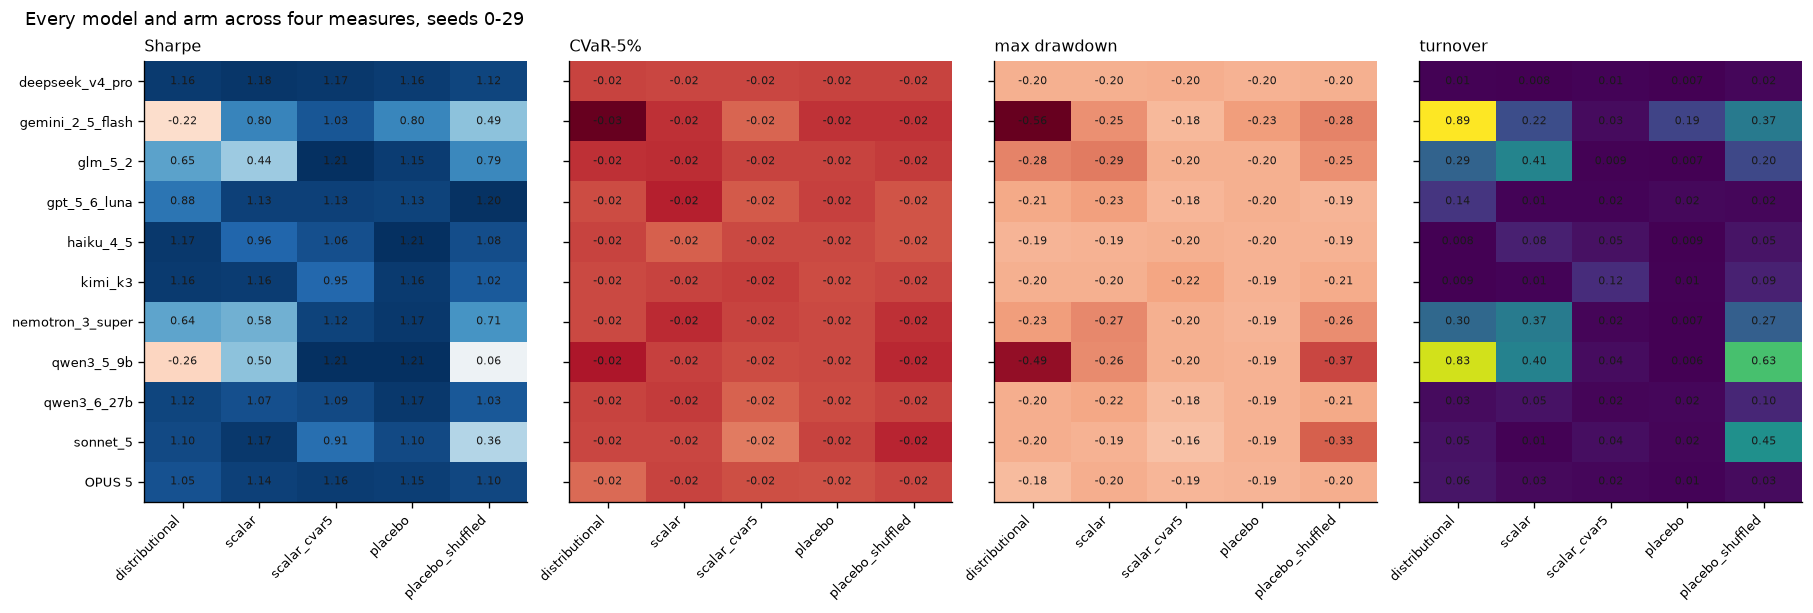

In [29]:
GRID = [("sharpe", "Sharpe"), ("oos_cvar_05", "CVaR-5%"), ("max_drawdown", "max drawdown"),
        ("turnover_mean", "turnover")]
ALL_LINES = LEG_ORDER + ["test"]

fig, axes = plt.subplots(1, len(GRID), figsize=(15.0, 5.0))
for ax, (col, name) in zip(axes, GRID):
    rowsg, labs = [], []
    for line in ALL_LINES:
        r = []
        for arm in LEG_ARMS:
            v = cell(line, arm, col).to_numpy()
            r.append(float(v.mean()) if v.size >= 5 else np.nan)
        rowsg.append(r); labs.append(pretty(line))
    Mg = np.array(rowsg)
    v = np.nanmax(np.abs(Mg))
    im = ax.imshow(Mg, cmap="RdBu" if col != "turnover_mean" else "viridis",
                   vmin=(-v if col != "turnover_mean" else np.nanmin(Mg)),
                   vmax=v if col != "turnover_mean" else np.nanmax(Mg), aspect="auto")
    ax.set_xticks(range(len(LEG_ARMS)))
    ax.set_xticklabels(LEG_ARMS, rotation=45, ha="right", fontsize=7.5)
    ax.set_yticks(range(len(labs)))
    ax.set_yticklabels(labs if col == GRID[0][0] else [""] * len(labs), fontsize=8)
    for i in range(Mg.shape[0]):
        for j in range(Mg.shape[1]):
            val = Mg[i, j]
            ax.text(j, i, "n/a" if np.isnan(val) else ("%.2f" % val if abs(val) >= 0.01 else "%.3f" % val),
                    ha="center", va="center", fontsize=6.4, color="0.1")
    ax.set_title(name, loc="left", fontsize=9.5); ax.grid(False)
fig.suptitle("Every model and arm across four measures, seeds 0-29", x=0.01, ha="left", fontsize=11)
savefig(fig, FIGDIR / "F25_full_grid.png")
plt.show()

**Figure 25. The complete model-by-arm grid on four measures.** Cells marked `n/a` have no data yet,
which on the Opus row is the confirmatory pair still running.

**What to conclude.** Most of the Sharpe panel is a fairly uniform blue a little above one, and that
uniformity is the easiest thing to overlook and one of the most important. **A language model handed
a reward-design task produces reward code that trains a profitable out-of-sample allocator in almost
every configuration on almost every model.** The failures are the exception.

**The variation concentrates in one column.** `distributional` holds the negative cells, and nothing
else in the grid goes below zero.

**The turnover panel is the mechanism panel.** Read it against the Sharpe panel and the arms that
trade most are the arms that score worst, which is the relation Section 18 established directly.

## 26. What this notebook does not establish

**Being explicit here is worth more than any additional analysis.** Every item is a real limit on
what may be claimed from the evidence above.

1. **No confirmatory result exists yet.** The single arm the pre-registration permits as the study's
   finding has zero records. Everything shown is report-only.
2. **These are not the registered estimators.** The frozen plan uses deflated Sharpe rather than raw
   Sharpe, interquartile means rather than means, seed-block bootstrap rather than the simple
   bootstrap here, and a formal equivalence test. Point estimates and intervals will move.
3. **The registered equivalence margin is deliberately not drawn on any figure.** The margin is 0.05
   in *deflated* Sharpe units and these axes are raw Sharpe. Shading a band of the right number in
   the wrong units would look rigorous and be wrong.
4. **The reported rung is zero, so nothing here is banked.** Results above the banked rung are real
   and stored, and they count in full once the rung beneath them closes.
5. **Thirty seeds cannot declare equivalence.** Section 16 measures the requirement directly and it
   runs into the hundreds on most models.
6. **The human canon is evaluated once, the automated arms are search winners.** Part of the H1 gap
   is selection rather than authorship, and the optimiser arms are the instrument that prices it.
7. **The turnover mechanism is a correlation across arms, not a controlled manipulation.** The cost
   model is linear and fixed, so the grid could be repriced without retraining. That sensitivity is
   not run here.
8. **The capability explanation for the Qwen split is a hypothesis.** It makes testable predictions
   through the responsiveness and mediation instruments, and none of them is tested in this
   notebook.
9. **The placebo result complicates the main contrast.** A matched-length block of nothing changes
   behaviour on some models, so length and format are not fully controlled by the arm design.
10. **Two archive gaps.** `wall_clock` is zero on every test record, so compute cannot be accounted
    from records. `train_curve["return"]` is NaN everywhere, so training progress cannot be plotted
    in reward units.
11. **Pooled histograms mix within-seed and between-seed variation.** They are the right exhibit for
    shape and the wrong one for inference, which is why every test is computed per seed and paired.
12. **No multiplicity correction is applied outside the ten-leg family.** The benchmark ladder, the
    grid and the control contrasts are descriptive.

## 27. Appendix: the full tables

Everything plotted above, printed, so any figure can be checked against the numbers behind it.

In [30]:
print("A1. EVERY (line, arm): the full performance panel at seeds 0-%d" % (FLOOR - 1))
full = (D[D["floor"]].groupby(["model", "arm"])
        .agg(n=("seed", "count"), **{lab: (col, "mean") for col, lab in PANEL_COLS}))
display(full)

A1. EVERY (line, arm): the full performance panel at seeds 0-29


n  Sharpe  ann.ret  ann.vol  Sortino  Calmar   maxDD  CVaR5%  CVaR1%   VaR5%    skew    kurt    hit  turnover  costdrag  Sharpe.gr   eff.N    HHI  \
model    arm                                                                                                                                                                                        
OPUS 5   baseline_differential_downside_ratio  30 -0.1710  -0.0291   0.1706  -0.1713 -0.0517 -0.4904 -0.0247 -0.0391 -0.0166  0.1063  9.0277 0.4905    0.8517    0.0009     1.0877  5.4240 0.2334   
         baseline_differential_sharpe          30 -0.1973  -0.0342   0.1731  -0.1898 -0.0494 -0.5111 -0.0252 -0.0398 -0.0169  0.1555  9.7898 0.4920    0.8527    0.0009     1.0464  5.4053 0.2525   
         baseline_log_growth                   30 -0.2009  -0.0401   0.1994  -0.2044 -0.0515 -0.5368 -0.0292 -0.0484 -0.0186  0.3221 12.0925 0.4784    0.8945    0.0009     0.9316  3.4657 0.3873   
         baseline_mean_variance_utility        30 -0.3003  -0.0608   0.2016  -0.3057 -0.0923 -0.5850 -0.0296 -0.0493 -0.0188  0.3334 13.6586 0.4749    0.8927    0.0009     0.8175  3.5417 0.3792   
         baseline_raw_return                   30 -0.3064  -0.0611   0.2003  -0.3128 -0.0955 -0.5833 -0.0291 -0.0487 -0.0186  0.3884 13.2490 0.4730    0.8935    0.0009     0.8203  3.5027 0.3855   
...                                            ..     ...      ...      ...      ...     ...     ...     ...     ...     ...     ...     ...    ...       ...       ...        ...     ...    ...   
sonnet_5 distributional                        30  1.0986   0.1530   0.1389   1.1067  0.7639 -0.2036 -0.0193 -0.0300 -0.0131 -0.0512  7.2910 0.5359    0.0475    0.0000     1.1861 11.3188 0.0909   
         placebo                               30  1.0981   0.1546   0.1405   1.1058  0.8162 -0.1941 -0.0195 -0.0310 -0.0131 -0.0420  7.6170 0.5369    0.0177    0.0000     1.1299 11.4282 0.0908   
         placebo_shuffled                      30  0.3575   0.0527   0.1533   0.3593  0.2648 -0.3324 -0.0220 -0.0345 -0.0148 -0.0229  8.0400 0.5118    0.4501    0.0005     1.0897 11.1751 0.1412   
         scalar                                30  1.1671   0.1628   0.1389   1.1745  0.8604 -0.1919 -0.0193 -0.0304 -0.0130 -0.0653  7.4391 0.5386    0.0109    0.0000     1.1868 13.0719 0.0778   
         scalar_cvar5                          30  0.9142   0.1019   0.1105   0.9213  0.6442 -0.1613 -0.0151 -0.0232 -0.0105  0.0326  6.6460 0.5322    0.0394    0.0000     1.0051  9.0245 0.1174   

                                               tot.ret  
model    arm                                            
OPUS 5   baseline_differential_downside_ratio  -0.2202  
         baseline_differential_sharpe          -0.2068  
         baseline_log_growth                   -0.2661  
         baseline_mean_variance_utility        -0.3658  
         baseline_raw_return                   -0.3673  
...                                                ...  
sonnet_5 distributional                         1.4794  
         placebo                                1.4988  
         placebo_shuffled                       0.4260  
         scalar                                 1.6345  
         scalar_cvar5                           0.8471  

[71 rows x 19 columns]

In [31]:
print("A2. H2 PAIRED CONTRAST, every metric, every model  (mean paired difference)")
allm = [c for c, _ in EFFECT_METRICS]
recs = []
for line in LEGS + (["test"] if HAS_OPUS else []):
    row = {"model": pretty(line)}
    for col in allm:
        d = paired(line, "distributional", "scalar", col)
        row[col] = float(d.mean()) if d.size else np.nan
    recs.append(row)
display(pd.DataFrame(recs).set_index("model"))

A2. H2 PAIRED CONTRAST, every metric, every model  (mean paired difference)


,sharpe,ann_return,ann_vol,sortino,calmar,max_drawdown,oos_cvar_05,oos_cvar_01,oos_left_tail_mass,oos_robust_skew,skew,kurtosis,hit_rate,turnover_mean,cost_drag,exp_eff_n,exp_hhi
model,,,,,,,,,,,,,,,,,
deepseek_v4_pro,-0.0154,-0.0005,0.0012,-0.0172,-0.0081,-0.0020,-0.0001,-0.0002,-0.0001,0.0018,-0.0100,-0.1656,0.0001,0.0027,0.0000,-1.5934,0.0113
gemini_2_5_flash,-1.0150,-0.1648,0.0482,-1.0165,-0.5539,-0.3020,-0.0077,-0.0153,-0.0001,0.0288,0.4536,7.0074,-0.0535,0.6730,0.0007,-6.2635,0.2738
glm_5_2,0.2074,0.0327,0.0008,0.2119,0.1389,0.0117,0.0001,0.0004,-0.0008,-0.0029,0.0220,-0.3391,0.0070,-0.1194,-0.0001,0.8717,-0.0175
gpt_5_6_luna,-0.2467,-0.0626,-0.0250,-0.2483,-0.2049,0.0188,0.0036,0.0052,-0.0004,0.0045,0.1180,2.0490,-0.0042,0.1271,0.0001,-2.1152,0.0228
haiku_4_5,0.2088,0.0430,0.0152,0.2154,0.2465,0.0020,-0.0023,-0.0042,0.0006,0.0064,-0.0508,0.5509,0.0031,-0.0767,-0.0001,3.0854,-0.0225
kimi_k3,0.0028,-0.0027,-0.0030,0.0054,-0.0168,-0.0001,0.0004,0.0007,0.0001,0.0027,-0.0059,0.0321,-0.0021,-0.0041,-0.0000,0.6870,-0.0065
nemotron_3_super,0.0601,-0.0031,-0.0166,0.0597,0.0463,0.0324,0.0023,0.0036,-0.0001,-0.0069,0.0251,0.0632,0.0011,-0.0687,-0.0001,5.0441,-0.0565
qwen3_5_9b,-0.7587,-0.1117,0.0227,-0.7574,-0.3639,-0.2272,-0.0035,-0.0059,0.0001,0.0062,0.2419,1.6537,-0.0261,0.4335,0.0004,-9.2037,0.1403
qwen3_6_27b,0.0458,0.0019,-0.0042,0.0469,0.0664,0.0135,0.0006,0.0005,-0.0017,-0.0003,-0.0361,0.2763,0.0002,-0.0166,-0.0000,2.4091,-0.0188


In [32]:
print("A3. DEPTH: records held per REGISTERED arm  (0 = in the design, no data)")
for line in LINES:
    print("  %s" % pretty(line))
    for arm in roster(line):
        n = int(((D["line"] == line) & (D["arm"] == arm)).sum())
        print("      %-40s %5d%s" % (arm, n, "   <-- NO DATA" if n == 0 else ""))

print()
print("A4. FIGURES WRITTEN")
for p in sorted(FIGDIR.glob("*.png")):
    print("   ", p.name)
print()
print("A5. RUN CONTEXT")
print("   records                :", len(D))
print("   derived columns        :", D.shape[1])
print("   common rung reported   :", COMMON_RUNG)
print("   exogenous stop         :", STOP_DATE)
print("   generated              :", NOW.strftime("%Y-%m-%d %H:%M:%SZ"))

A3. DEPTH: records held per REGISTERED arm  (0 = in the design, no data)
  OPUS 5
      distributional                              30
      scalar                                      30
      scalar_cvar5                                30
      placebo                                     30
      placebo_shuffled                            30
      random_search                               30
      bayes_opt                                   30
      cma_es                                      30
      tpe                                         30
      baseline_differential_downside_ratio        30
      baseline_differential_sharpe                30
      baseline_log_growth                         30
      baseline_mean_variance_utility              30
      baseline_raw_return                         30
      baseline_return_minus_cvar                  30
      baseline_return_minus_downside              30
      baseline_return_minus_drawdown              30
      baseline_re

## What happens next

**The confirmatory arm closes the floor, and then the whole fleet climbs together.**

1. The Opus H2 pair test finishes and rung 30 banks. That is the first reportable result the
   campaign will have produced, and it fills Section 4 and every reserved row above.
2. Opus joins the other models on the ladder toward rung 100 and rung 189. Section 16 is the reason
   that matters more than it might appear: precision, not accuracy, is what is missing.
3. The registered analysis runs, replacing every descriptive estimator here with the frozen ones.
4. Three mechanism checks become due: the cost-sensitivity sweep implied by Section 18, the
   responsiveness and mediation instruments against the capability story in Section 11, and the
   structural distance measures on the authored programs in Section 21.

**To refresh this notebook**, set `FORCE_RELOAD = True` in the setup cell and run all cells. Every
figure, table and reserved panel updates from the archive.